# Wczytanie bibliotek

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from scipy.stats import shapiro, normaltest, anderson
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import missingno as msno
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
import time
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import KernelPCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.inspection import permutation_importance
from sklearn.decomposition import KernelPCA


# Wstępna Analiza

In [ ]:
MigracjeZbiór = pd.read_csv('PolskaMigracjeDane.csv', sep=';', encoding='cp1250', decimal=',')
print("Pierwsze 5 wierszy\n")
print(MigracjeZbiór.head(5))
print("\nInformacje o typach danych:")
print(MigracjeZbiór.info())
print("\nStatystyki opisowe")
print(MigracjeZbiór.describe())

Pierwsze 5 wierszy

   Województwo i rok  Produkt_Krajowy_Brutto_na_mieszkańca_(zł)  \
0  Dolnośląskie_2010                                      42295   
1  Dolnośląskie_2011                                      46296   
2  Dolnośląskie_2012                                      47986   
3  Dolnośląskie_2013                                      48179   
4  Dolnośląskie_2014                                      50031   

   Stopa_bezrobocia_rejestrowanego_(%)  \
0                                 13.1   
1                                 12.4   
2                                 13.5   
3                                 13.1   
4                                 10.4   

   Przeciętne_miesięczne_wynagrodzenie_brutto_(czwarty_kwartał)_(zł)  \
0                                            3655.84                   
1                                            3830.15                   
2                                            3879.12                   
3                                   

In [ ]:
print("Brakujące wartości:")
print(MigracjeZbiór.isnull().sum().sort_values(ascending=False).head(20))
#Brak brakujących wartości

print("\nTypy zmiennych:")
print(MigracjeZbiór.dtypes.value_counts())

Brakujące wartości:
Województwo i rok                                                    0
Produkt_Krajowy_Brutto_na_mieszkańca_(zł)                            0
Stopa_bezrobocia_rejestrowanego_(%)                                  0
Przeciętne_miesięczne_wynagrodzenie_brutto_(czwarty_kwartał)_(zł)    0
Liczba_ludności_w_wieku_produkcyjnym_na_1000_ludności                0
Liczba_ludności_w_wieku_przedprodukcyjnym_na_1000_ludności           0
Liczba_ludności_w_wieku_poprodukcyjnym_na_1000_ludności              0
Gęstość_zaludnienia_(osoba/km^2)                                     0
Przyrost_naturalny_na_1000_ludności                                  0
Liczba_urodzeń_na_1000_ludności                                      0
Przeciętne_trwanie_życia_(lata)                                      0
Liczba_małżeństw_na_1000_ludności                                    0
Zezwolenia_na_pracę_dla_cudzoziemców_na_1000_ludności                0
Liczba_studentów_na_10000_ludności                       

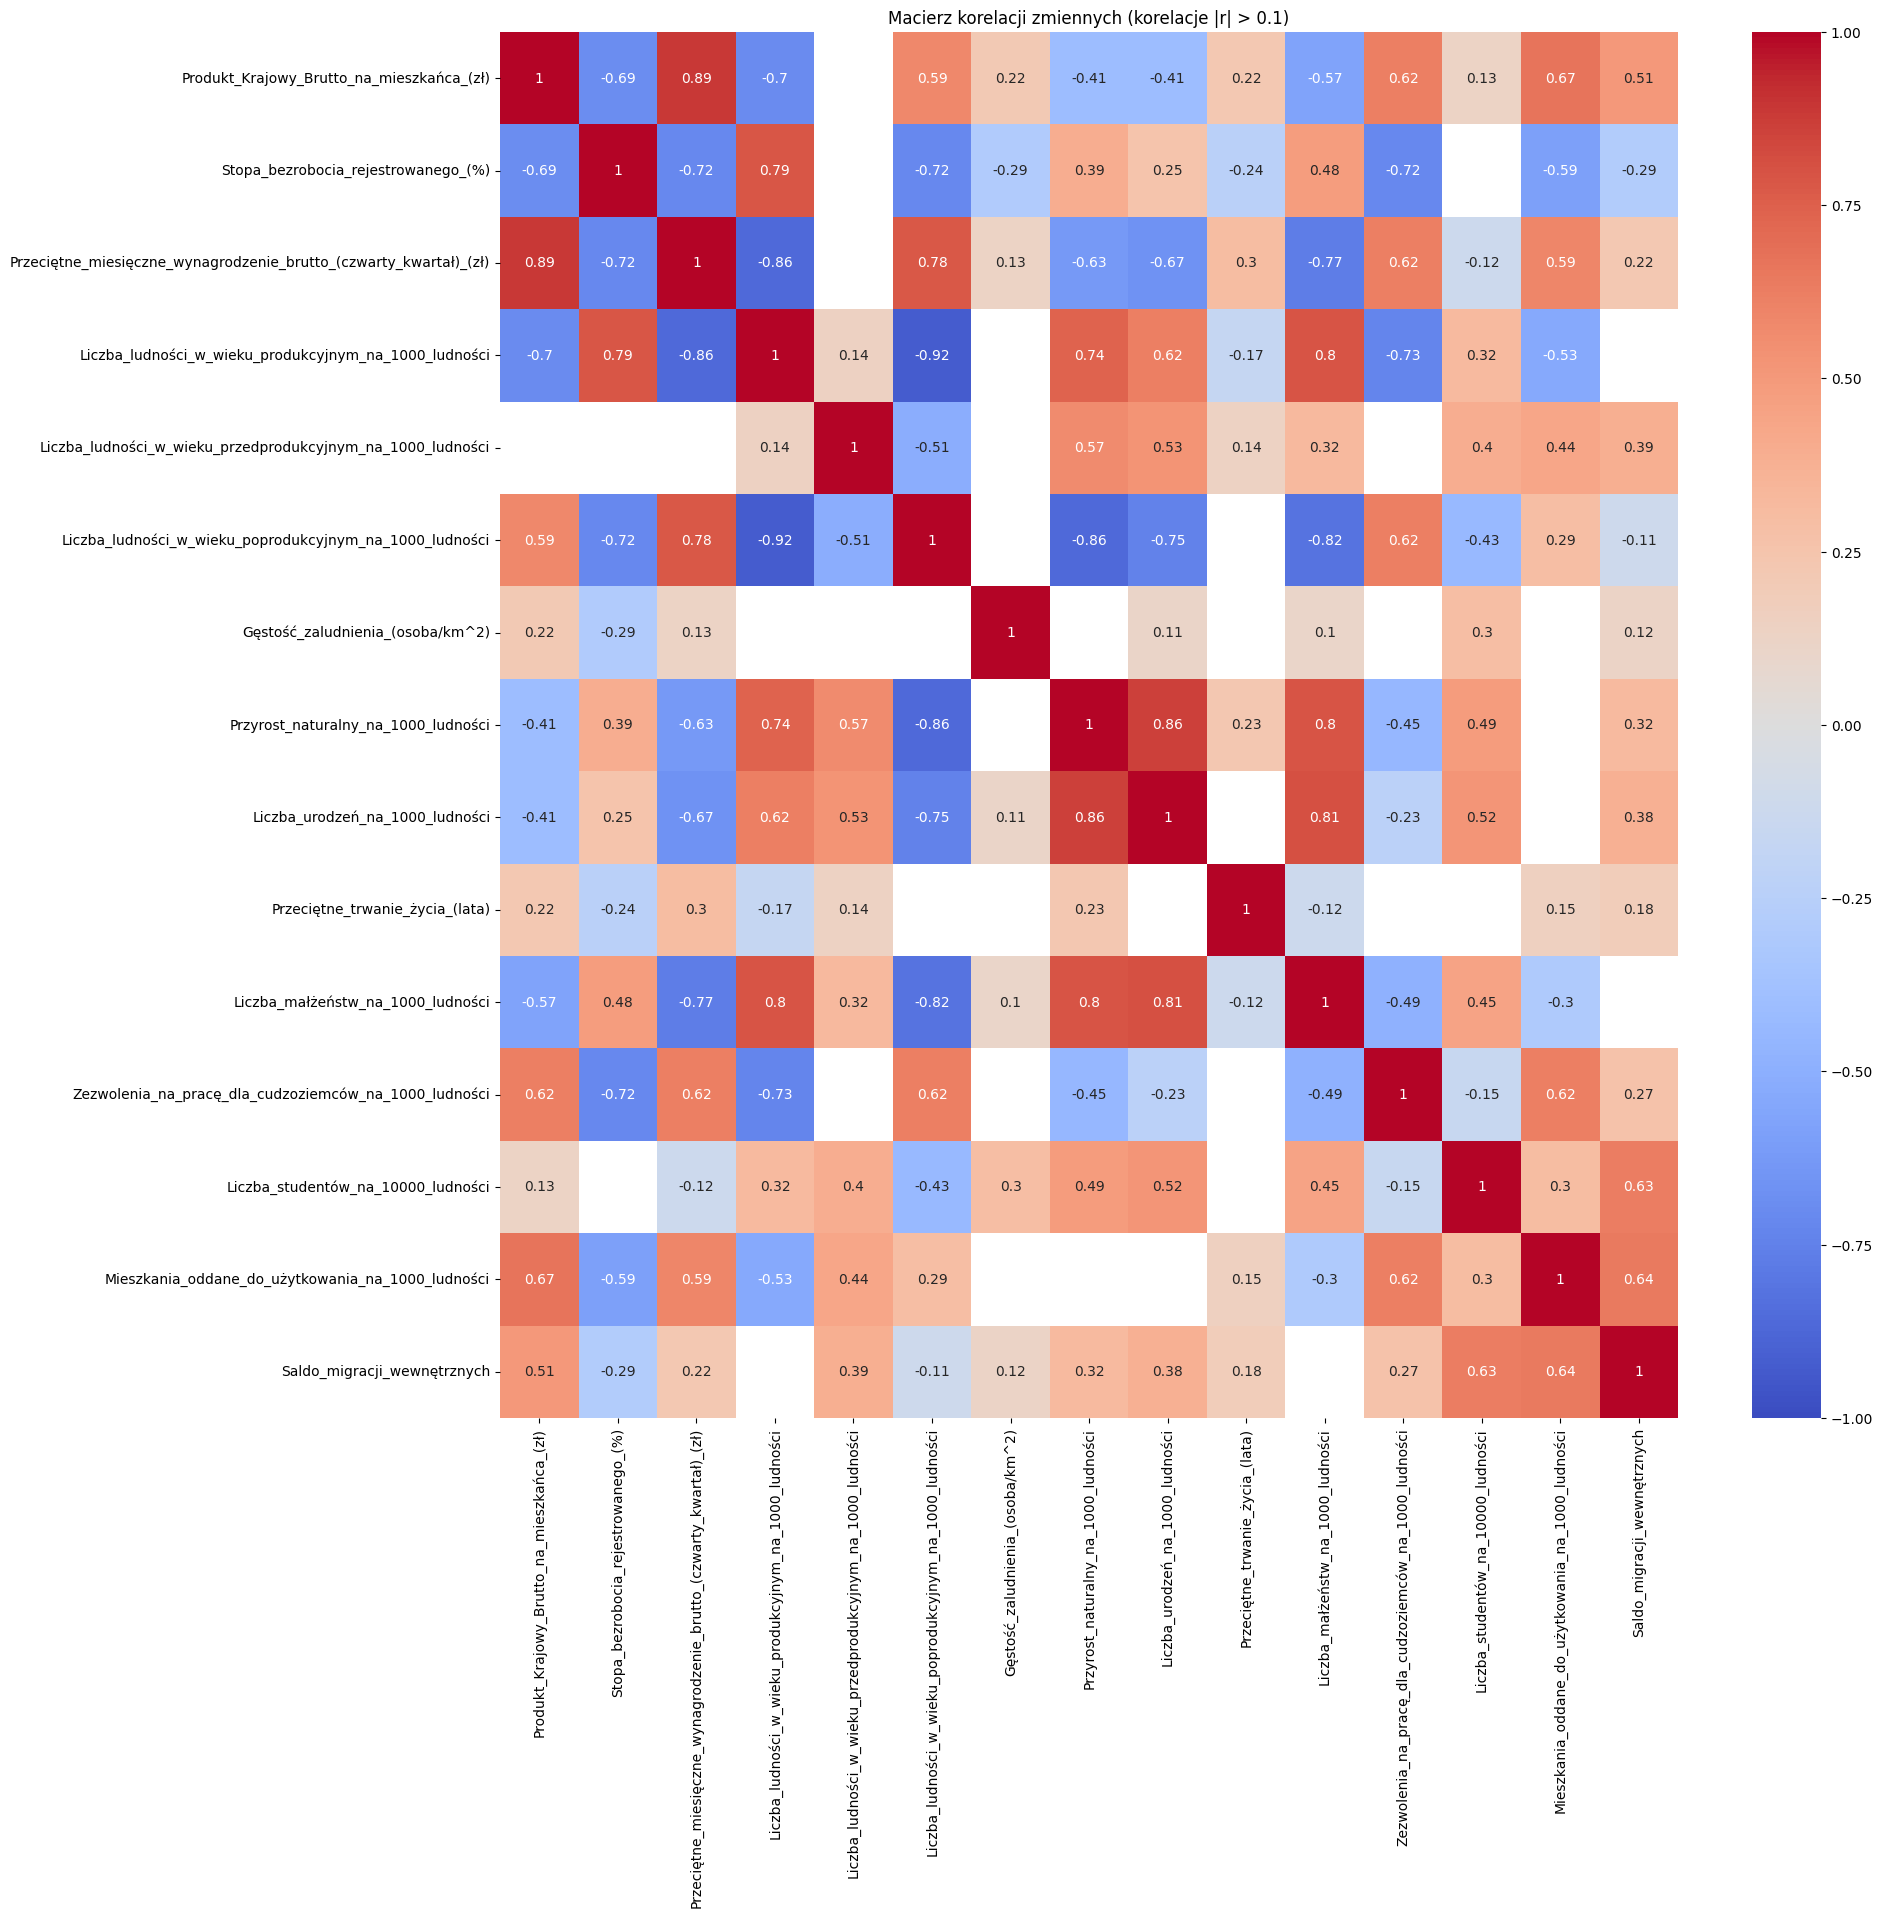

In [ ]:
columns = MigracjeZbiór.select_dtypes(include=[np.number]).columns
corr_matrix = MigracjeZbiór[columns].corr()

plt.figure(figsize=(19,18))
sns.heatmap(corr_matrix[(corr_matrix > 0.1) | (corr_matrix < -0.1)],
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Macierz korelacji zmiennych (korelacje |r| > 0.1)")
plt.show()

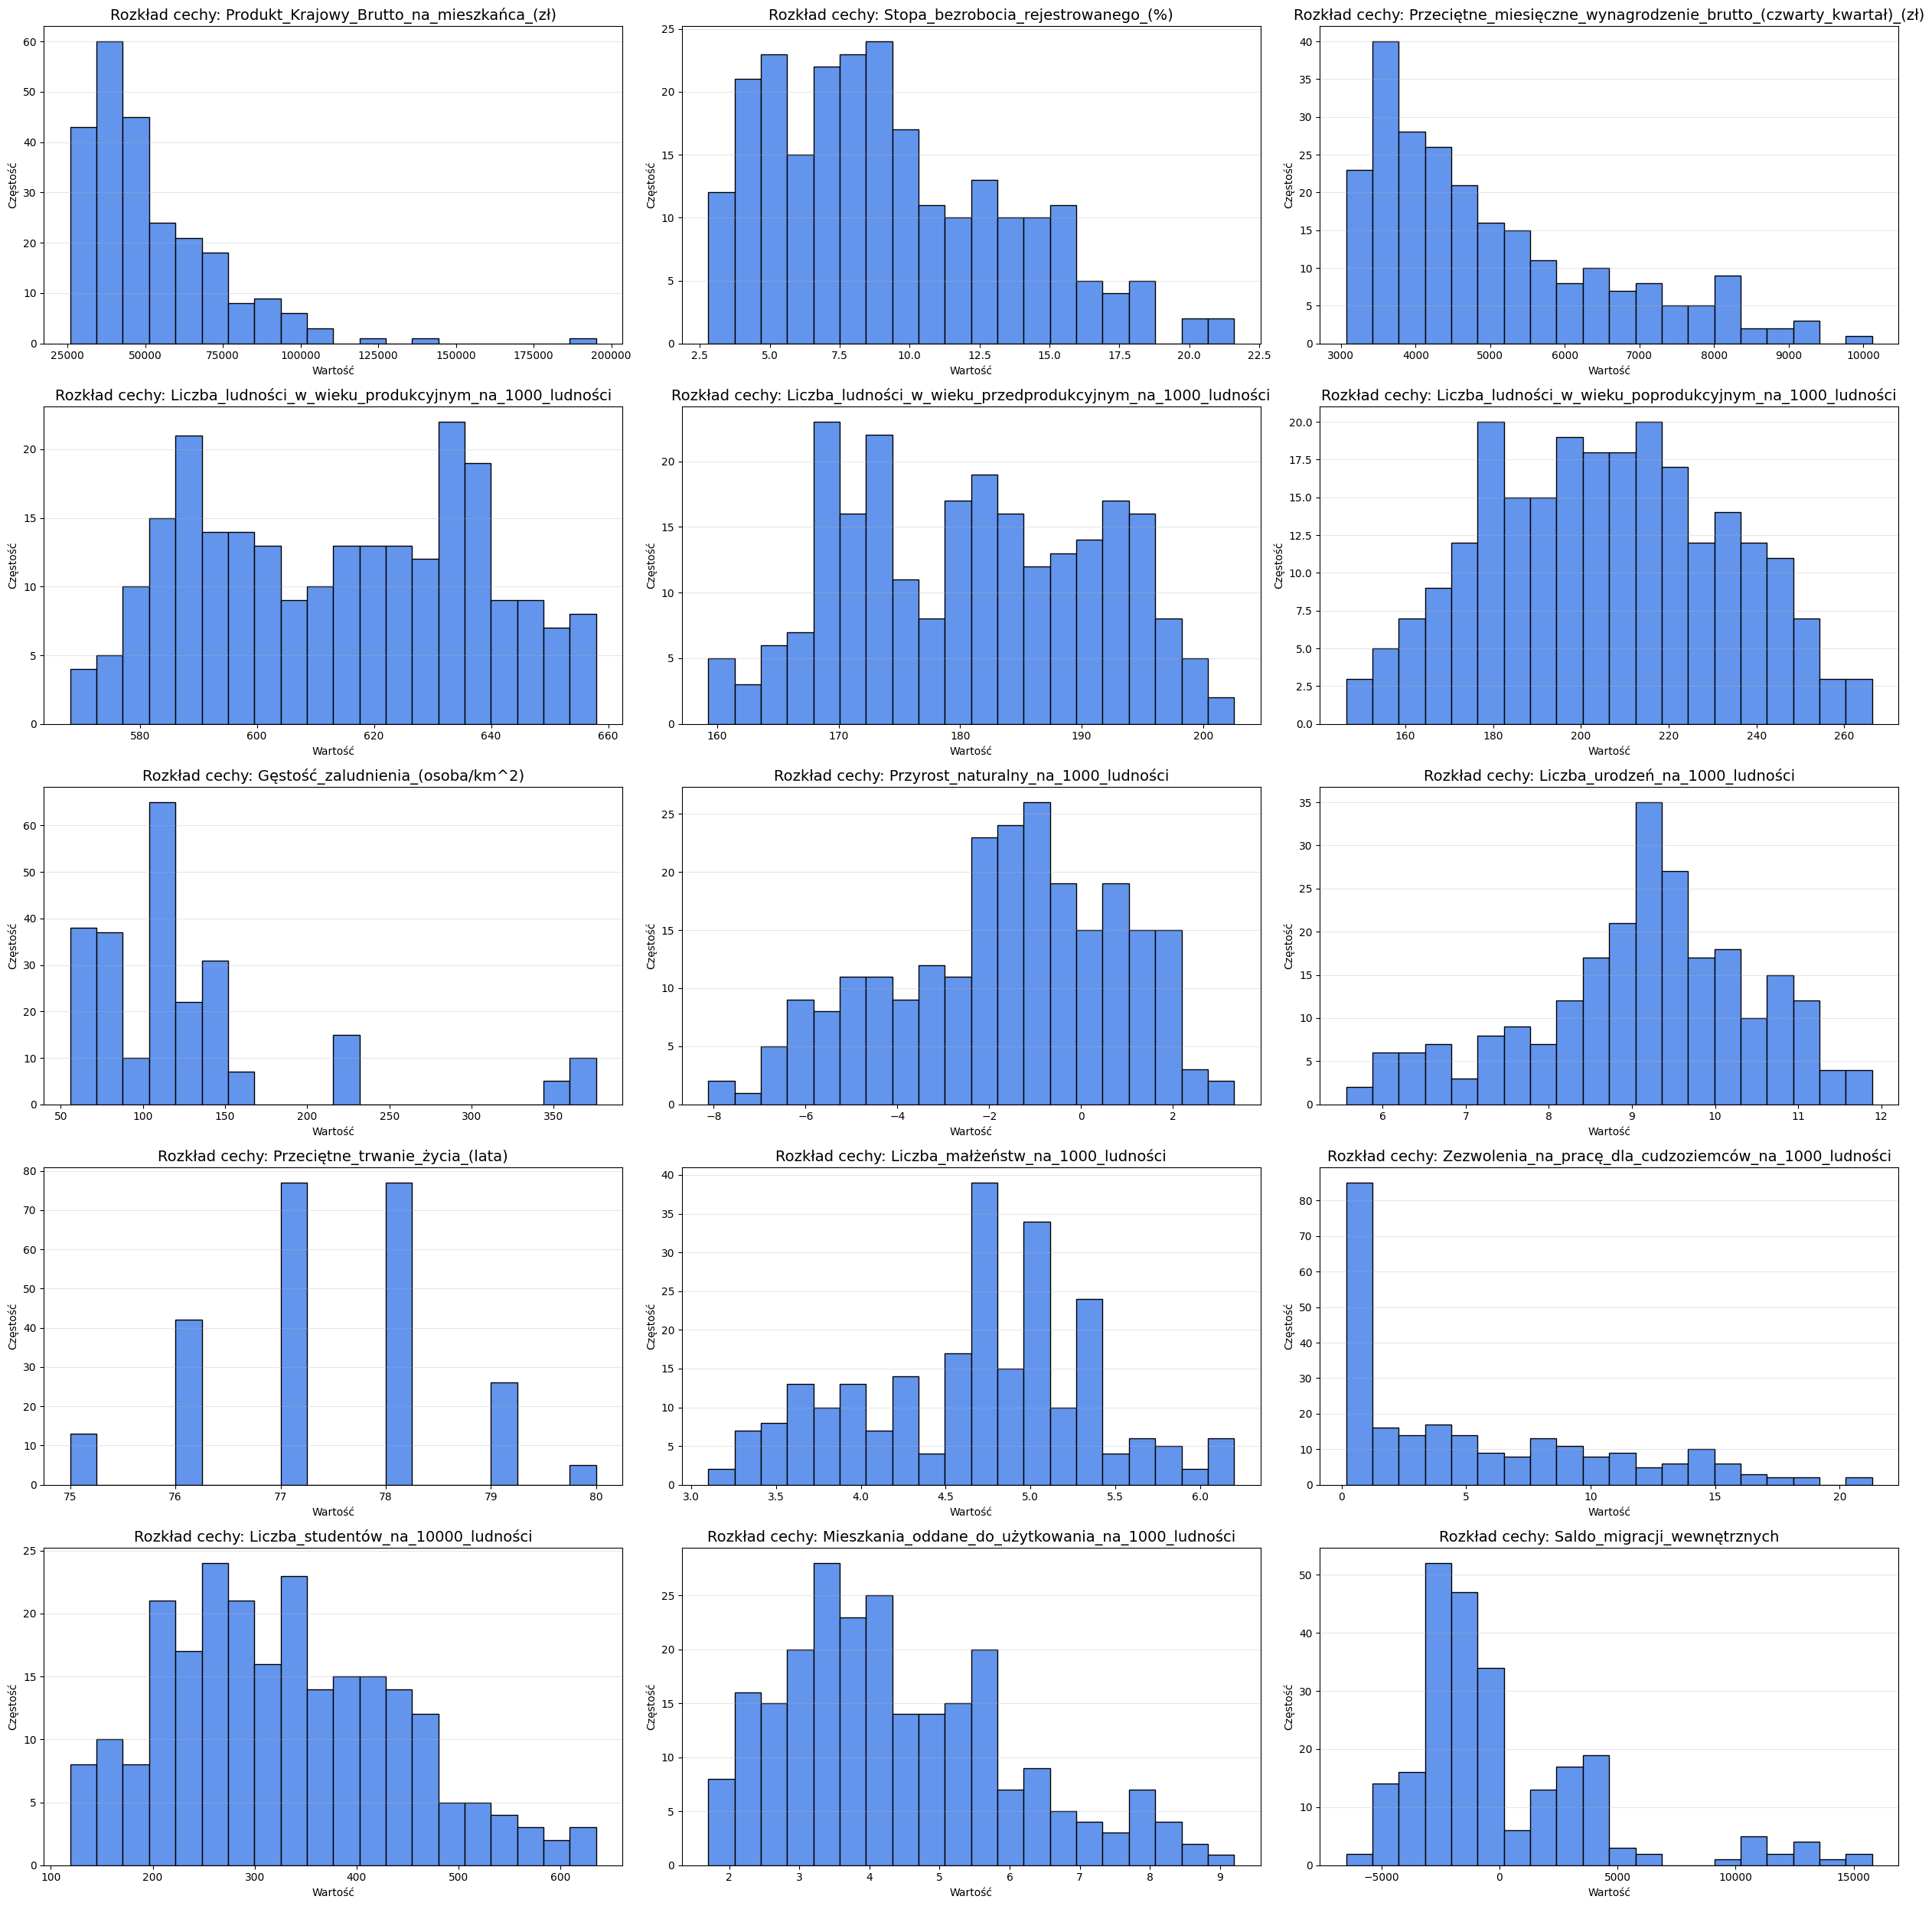

In [ ]:
n_cols = 3  #Ile wykresów w rzędzie
n_rows = (len(columns) + n_cols - 1) // n_cols  #Automatyczne obliczenie liczby wierszy i dynamiczne dopasowanie wysokości

plt.figure(figsize=(25, n_rows * 5))

for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.hist(MigracjeZbiór[col].dropna(), bins=20, color='cornflowerblue', edgecolor='black')
    plt.title(f'Rozkład cechy: {col}', fontsize=14)
    plt.xlabel('Wartość')
    plt.ylabel('Częstość')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#Testy normalności dla cech numerycznych
test_columns = ['Saldo_migracji_wewnętrznych', 'Produkt_Krajowy_Brutto_na_mieszkańca_(zł)',
                'Stopa_bezrobocia_rejestrowanego_(%)','Gęstość_zaludnienia_(osoba/km^2)',
                'Przeciętne_miesięczne_wynagrodzenie_brutto_(czwarty_kwartał)_(zł)', 'Liczba_ludności_w_wieku_produkcyjnym_na_1000_ludności',
                'Liczba_ludności_w_wieku_poprodukcyjnym_na_1000_ludności', 'Liczba_ludności_w_wieku_przedprodukcyjnym_na_1000_ludności',
                'Gęstość_zaludnienia_(osoba/km^2)', 'Przyrost_naturalny_na_1000_ludności',
                'Liczba_urodzeń_na_1000_ludności', 'Przeciętne_trwanie_życia_(lata)',
                'Liczba_małżeństw_na_1000_ludności', 'Zezwolenia_na_pracę_dla_cudzoziemców_na_1000_ludności',
                'Liczba_studentów_na_10000_ludności', 'Mieszkania_oddane_do_użytkowania_na_1000_ludności']
for column in test_columns:
    print(f"\nCecha: {column}")

    if MigracjeZbiór[column].notna().sum() < 3:
        print("Za mało danych do testu")
        continue

    #Shapiro-Wilk
    stat_sw, p_sw = shapiro(MigracjeZbiór[column].dropna())
    print(f" Shapiro-Wilk: stat={stat_sw:.4f}, p={p_sw:.4f} --> {'normalny' if p_sw > 0.05 else 'nienormalny'}")

    #D'Agostino Pearson
    stat_dp, p_dp = normaltest(MigracjeZbiór[column].dropna())
    print(f" D'Agostino-Pearson: stat={stat_dp:.4f}, p={p_dp:.4f} --> {'normalny' if p_dp > 0.05 else 'nienormalny'}")

    #Anderson-Darling
    result_ad = anderson(MigracjeZbiór[column].dropna(), dist='norm')
    ad_stat = result_ad.statistic
    ad_crit_val = result_ad.critical_values[2]
    print(f" Anderson-Darling: stat={ad_stat:.4f}, crit(5%)={ad_crit_val:.4f} --> {'normalny' if ad_stat < ad_crit_val else 'nienormalny'}")
    print("-" * 50)


Cecha: Saldo_migracji_wewnętrznych
 Shapiro-Wilk: stat=0.8264, p=0.0000 --> nienormalny
 D'Agostino-Pearson: stat=87.2341, p=0.0000 --> nienormalny
 Anderson-Darling: stat=13.0717, crit(5%)=0.7740 --> nienormalny
--------------------------------------------------

Cecha: Produkt_Krajowy_Brutto_na_mieszkańca_(zł)
 Shapiro-Wilk: stat=0.8384, p=0.0000 --> nienormalny
 D'Agostino-Pearson: stat=126.6344, p=0.0000 --> nienormalny
 Anderson-Darling: stat=8.1400, crit(5%)=0.7740 --> nienormalny
--------------------------------------------------

Cecha: Stopa_bezrobocia_rejestrowanego_(%)
 Shapiro-Wilk: stat=0.9526, p=0.0000 --> nienormalny
 D'Agostino-Pearson: stat=15.6868, p=0.0004 --> nienormalny
 Anderson-Darling: stat=3.1802, crit(5%)=0.7740 --> nienormalny
--------------------------------------------------

Cecha: Gęstość_zaludnienia_(osoba/km^2)
 Shapiro-Wilk: stat=0.7393, p=0.0000 --> nienormalny
 D'Agostino-Pearson: stat=111.9623, p=0.0000 --> nienormalny
 Anderson-Darling: stat=18.78

#Wykresy pudełkowe przed standaryzacją

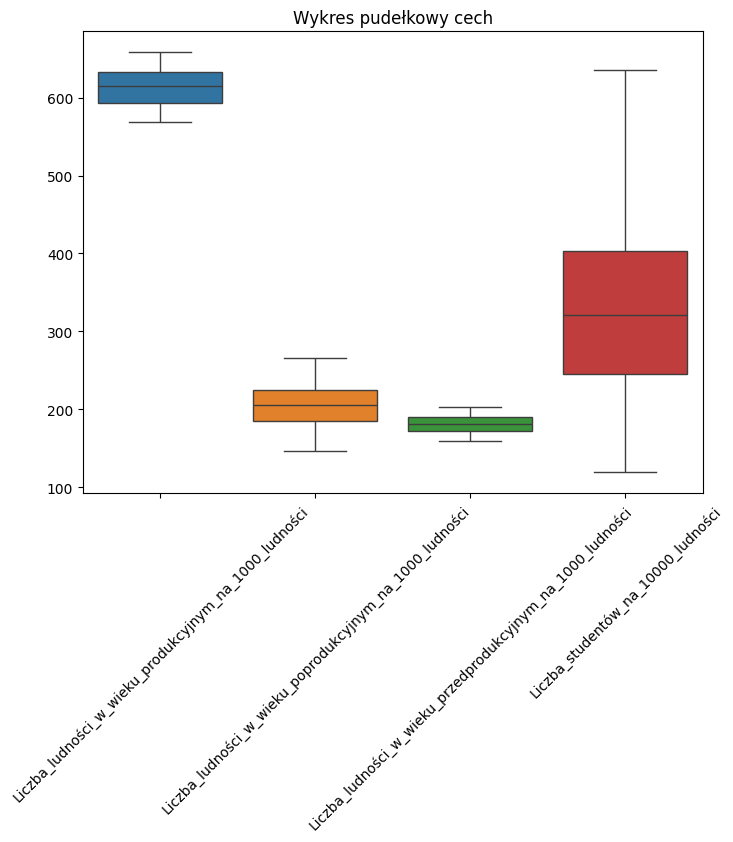

In [ ]:
#Wykres pudełkowy dla cech numerycznych w obencym stanie
plt.figure(figsize=(8,6))
sns.boxplot(data=MigracjeZbiór[[
                'Liczba_ludności_w_wieku_produkcyjnym_na_1000_ludności', 'Liczba_ludności_w_wieku_poprodukcyjnym_na_1000_ludności',
                'Liczba_ludności_w_wieku_przedprodukcyjnym_na_1000_ludności', 'Liczba_studentów_na_10000_ludności', ]])
plt.title('Wykres pudełkowy cech')
plt.xticks(rotation=45)
plt.show()

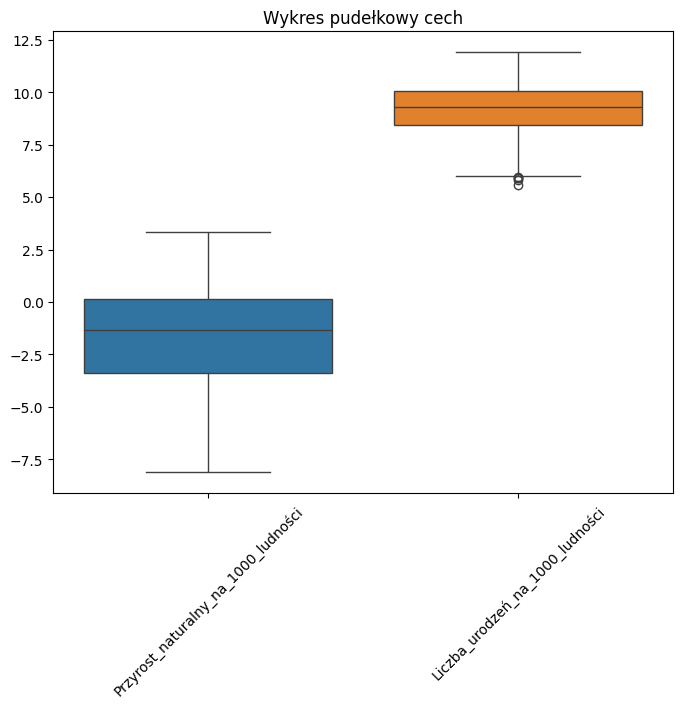

In [ ]:
#Wykres pudełkowy dla cech numerycznych w obencym stanie
plt.figure(figsize=(8,6))
sns.boxplot(data=MigracjeZbiór[[
                'Przyrost_naturalny_na_1000_ludności',
                'Liczba_urodzeń_na_1000_ludności']])
plt.title('Wykres pudełkowy cech')
plt.xticks(rotation=45)
plt.show()

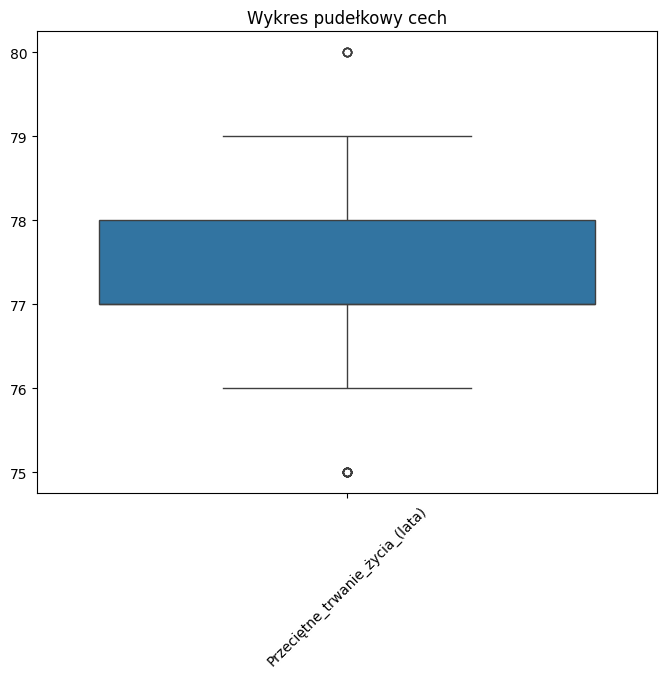

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=MigracjeZbiór[[
'Przeciętne_trwanie_życia_(lata)' ]])
plt.title('Wykres pudełkowy cech')
plt.xticks(rotation=45)
plt.show()

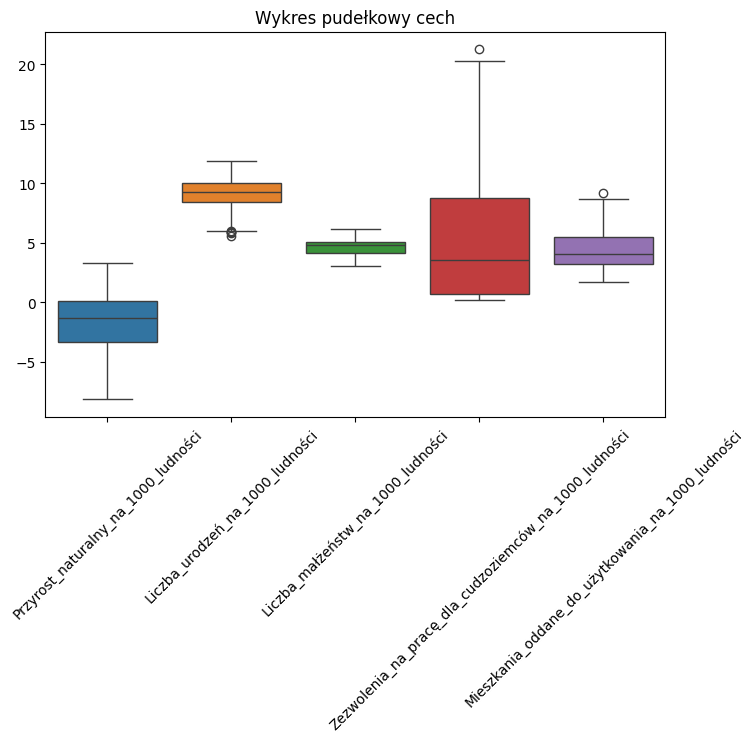

In [ ]:
#Wykres pudełkowy dla cech numerycznych w obencym stanie
plt.figure(figsize=(8,5))
sns.boxplot(data=MigracjeZbiór[[
                'Przyrost_naturalny_na_1000_ludności',
                'Liczba_urodzeń_na_1000_ludności',
                'Liczba_małżeństw_na_1000_ludności', 'Zezwolenia_na_pracę_dla_cudzoziemców_na_1000_ludności', 'Mieszkania_oddane_do_użytkowania_na_1000_ludności']])
plt.title('Wykres pudełkowy cech')
plt.xticks(rotation=45)
plt.show()

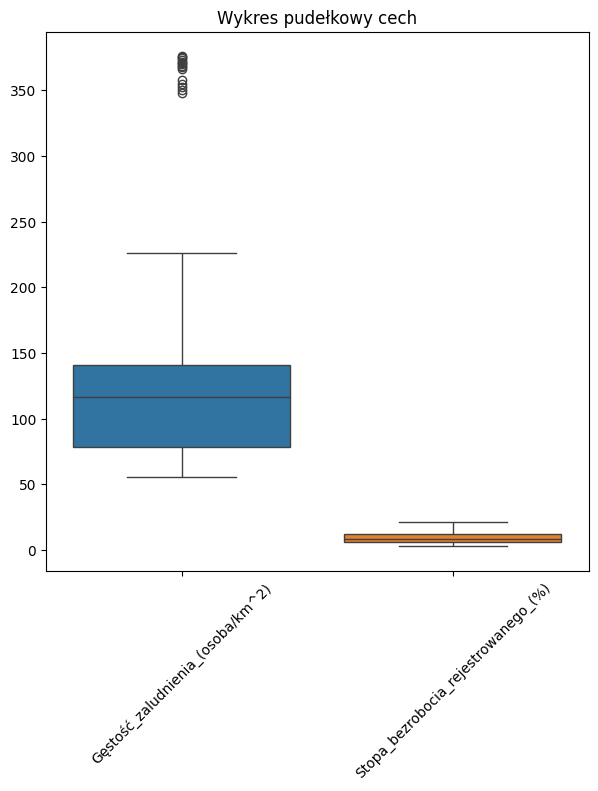

In [ ]:
#Wykres pudełkowy dla cech numerycznych w obencym stanie
plt.figure(figsize=(7,7))
sns.boxplot(data=MigracjeZbiór[['Gęstość_zaludnienia_(osoba/km^2)','Stopa_bezrobocia_rejestrowanego_(%)', ]])
plt.title('Wykres pudełkowy cech')
plt.xticks(rotation=45)
plt.show()

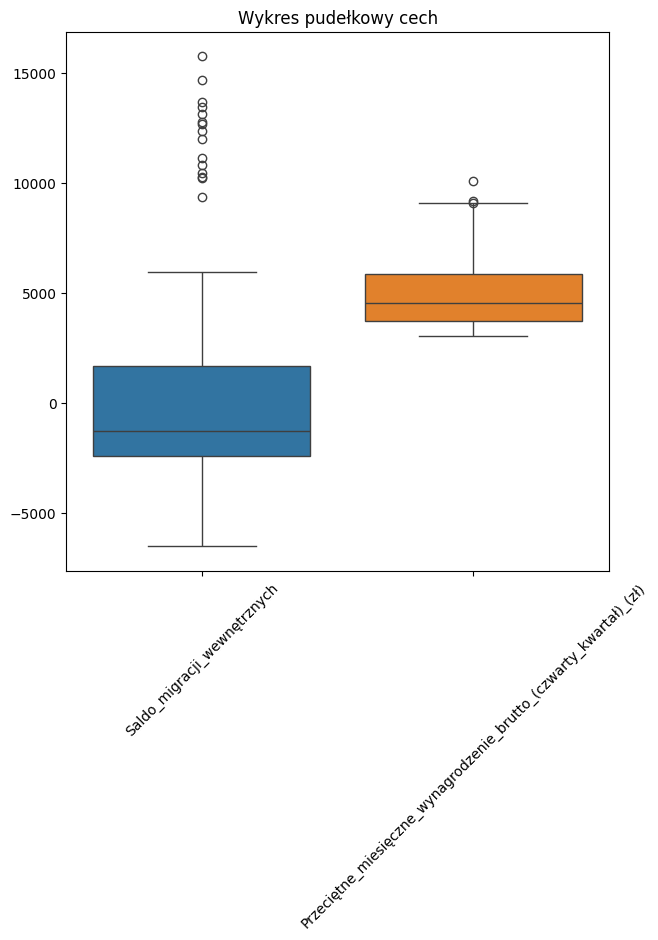

In [ ]:
#Wykres pudełkowy dla cech numerycznych w obencym stanie
plt.figure(figsize=(7,7))
sns.boxplot(data=MigracjeZbiór[['Saldo_migracji_wewnętrznych','Przeciętne_miesięczne_wynagrodzenie_brutto_(czwarty_kwartał)_(zł)']])
plt.title('Wykres pudełkowy cech')
plt.xticks(rotation=45)
plt.show()

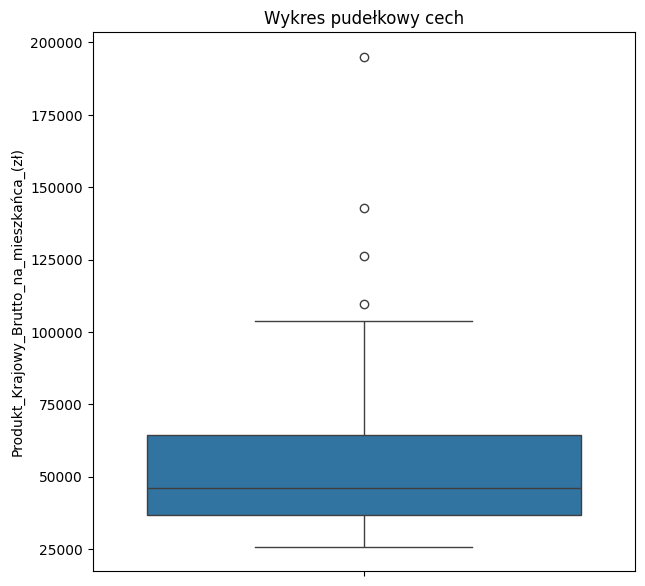

In [ ]:
#Wykres pudełkowy dla cech numerycznych w obencym stanie
plt.figure(figsize=(7,7))
sns.boxplot(data=MigracjeZbiór['Produkt_Krajowy_Brutto_na_mieszkańca_(zł)'])
plt.title('Wykres pudełkowy cech')
plt.xticks(rotation=45)
plt.show()

# Wykresy pudełkowe po standaryzacji

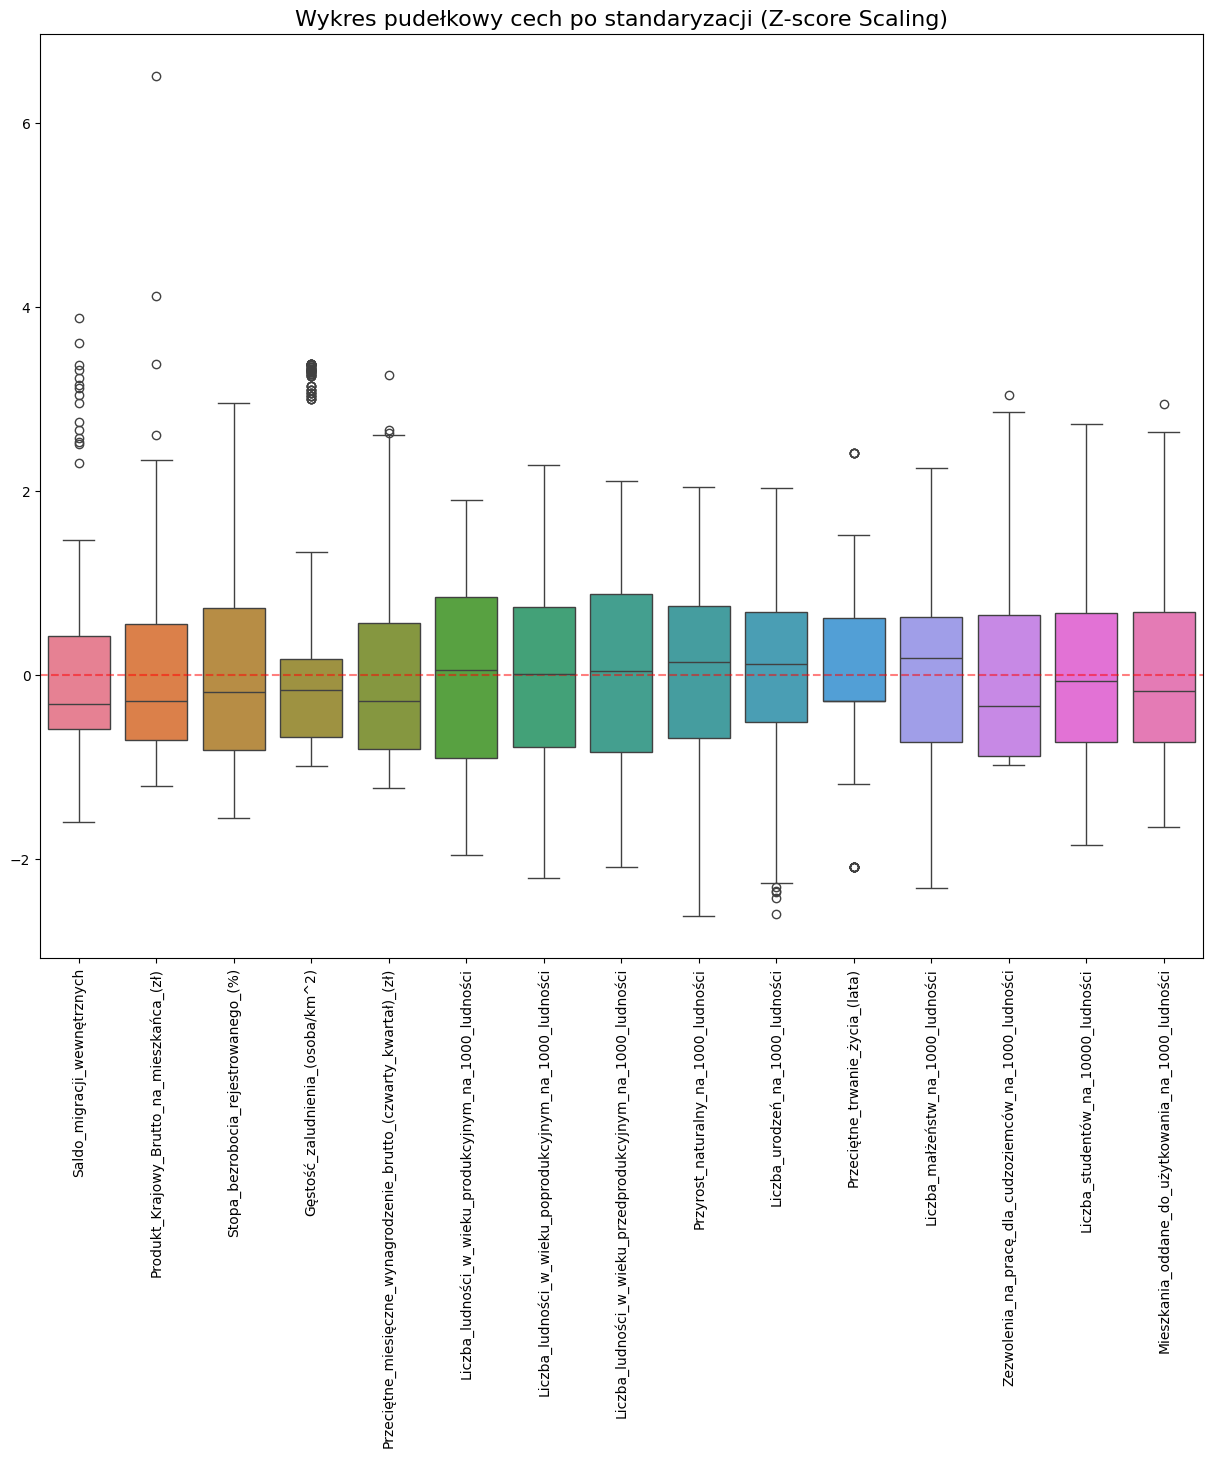

In [ ]:
scaler1 = StandardScaler()
Migracje_Scaled = MigracjeZbiór.copy()
Migracje_Scaled[test_columns] = scaler1.fit_transform(MigracjeZbiór[test_columns])

plt.figure(figsize=(15, 12))
sns.boxplot(data=Migracje_Scaled[test_columns])
plt.title('Wykres pudełkowy cech po standaryzacji (Z-score Scaling)', fontsize=16)
plt.xticks(rotation=90)
plt.axhline(0, color='red', linestyle='--', alpha=0.5) #Linia średniej
plt.show()

# Regresja bez PCA i Feature Importance



In [ ]:
X = MigracjeZbiór.drop('Saldo_migracji_wewnętrznych', axis=1) #Przygotowanie danych
y = MigracjeZbiór['Saldo_migracji_wewnętrznych']

#Podział danych na treningowe i testowe (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=None)

print("Rozmiar zbiorów:\n")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Rozmiar zbiorów:

X_train: (168, 15)
X_test : (72, 15)
y_train: (168,)
y_test : (72,)


In [ ]:
#Definicja modeli do testowania
models = {
    'Ridge Regression': Ridge(),
    'SVR (RBF)': SVR(kernel='rbf', C=1000, epsilon=0.1, gamma='auto'),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}
#Lista na wyniki
results_list = []

#Definicja preprocesora- int i flaot
num_features = X.select_dtypes(include=['int64', 'float64']).columns
preprocessor = ColumnTransformer([('num', StandardScaler(), num_features)])

In [ ]:
#Dobranie parametrów z Gridsearch dla SVR
svr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', SVR(kernel='rbf'))
])

#Definicja siatki parametrów
#C: kontroluje kompromis między błędem a gładkością funkcji
#gamma: określa zasięg wpływu pojedynczego punktu treningowego
#epsilon: określa ramę błędu, w której nie naliczane są kary
param_grid = {
    'regressor__C': [0.1, 1, 10, 100, 1000],
    'regressor__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'regressor__epsilon': [0.1, 0.2, 0.5, 1.0]
}

grid_search = GridSearchCV(
    svr_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Rozpoczynam szukanie optymalnych parametrów dla SVR...")
grid_search.fit(X_train, y_train)

#Wyciągnięcie najlepszego modelu
best_svr = grid_search.best_estimator_
print(f"\nNajlepsze parametry: {grid_search.best_params_}")

y_pred_test_svr = best_svr.predict(X_test)
y_pred_train_svr = best_svr.predict(X_train)

new_svr_r2 = r2_score(y_test, y_pred_test_svr)
new_svr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_svr))

print(f"Nowy R2 dla SVR po tuningu: {new_svr_r2:.3f}")

Rozpoczynam szukanie optymalnych parametrów dla SVR...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Najlepsze parametry: {'regressor__C': 1000, 'regressor__epsilon': 0.1, 'regressor__gamma': 'auto'}
Nowy R2 dla SVR po tuningu: 0.704


Zakończono trenowanie: Ridge Regression
Zakończono trenowanie: SVR (RBF)
Obliczam Permutation Importance dla SVR (RBF) (to może chwilę potrwać)...
Zakończono trenowanie: Random Forest
Zakończono trenowanie: Gradient Boosting


,Metoda,Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Cross-val R2 mean,Czas trenowania [s],Liczba cech
0,Ridge Regression,0.805150,0.696790,1817.688020,2168.001014,1423.138438,1559.560391,0.740982,0.090154,15
1,SVR (RBF),0.759230,0.703961,2020.552890,2142.209277,1019.603383,1164.627975,0.683486,0.037750,15
2,Random Forest,0.986741,0.913253,474.150981,1159.617543,265.319464,736.588056,0.897583,0.761786,15
3,Gradient Boosting,0.997090,0.918950,222.120305,1120.896818,175.117797,772.466544,0.886637,0.522103,15


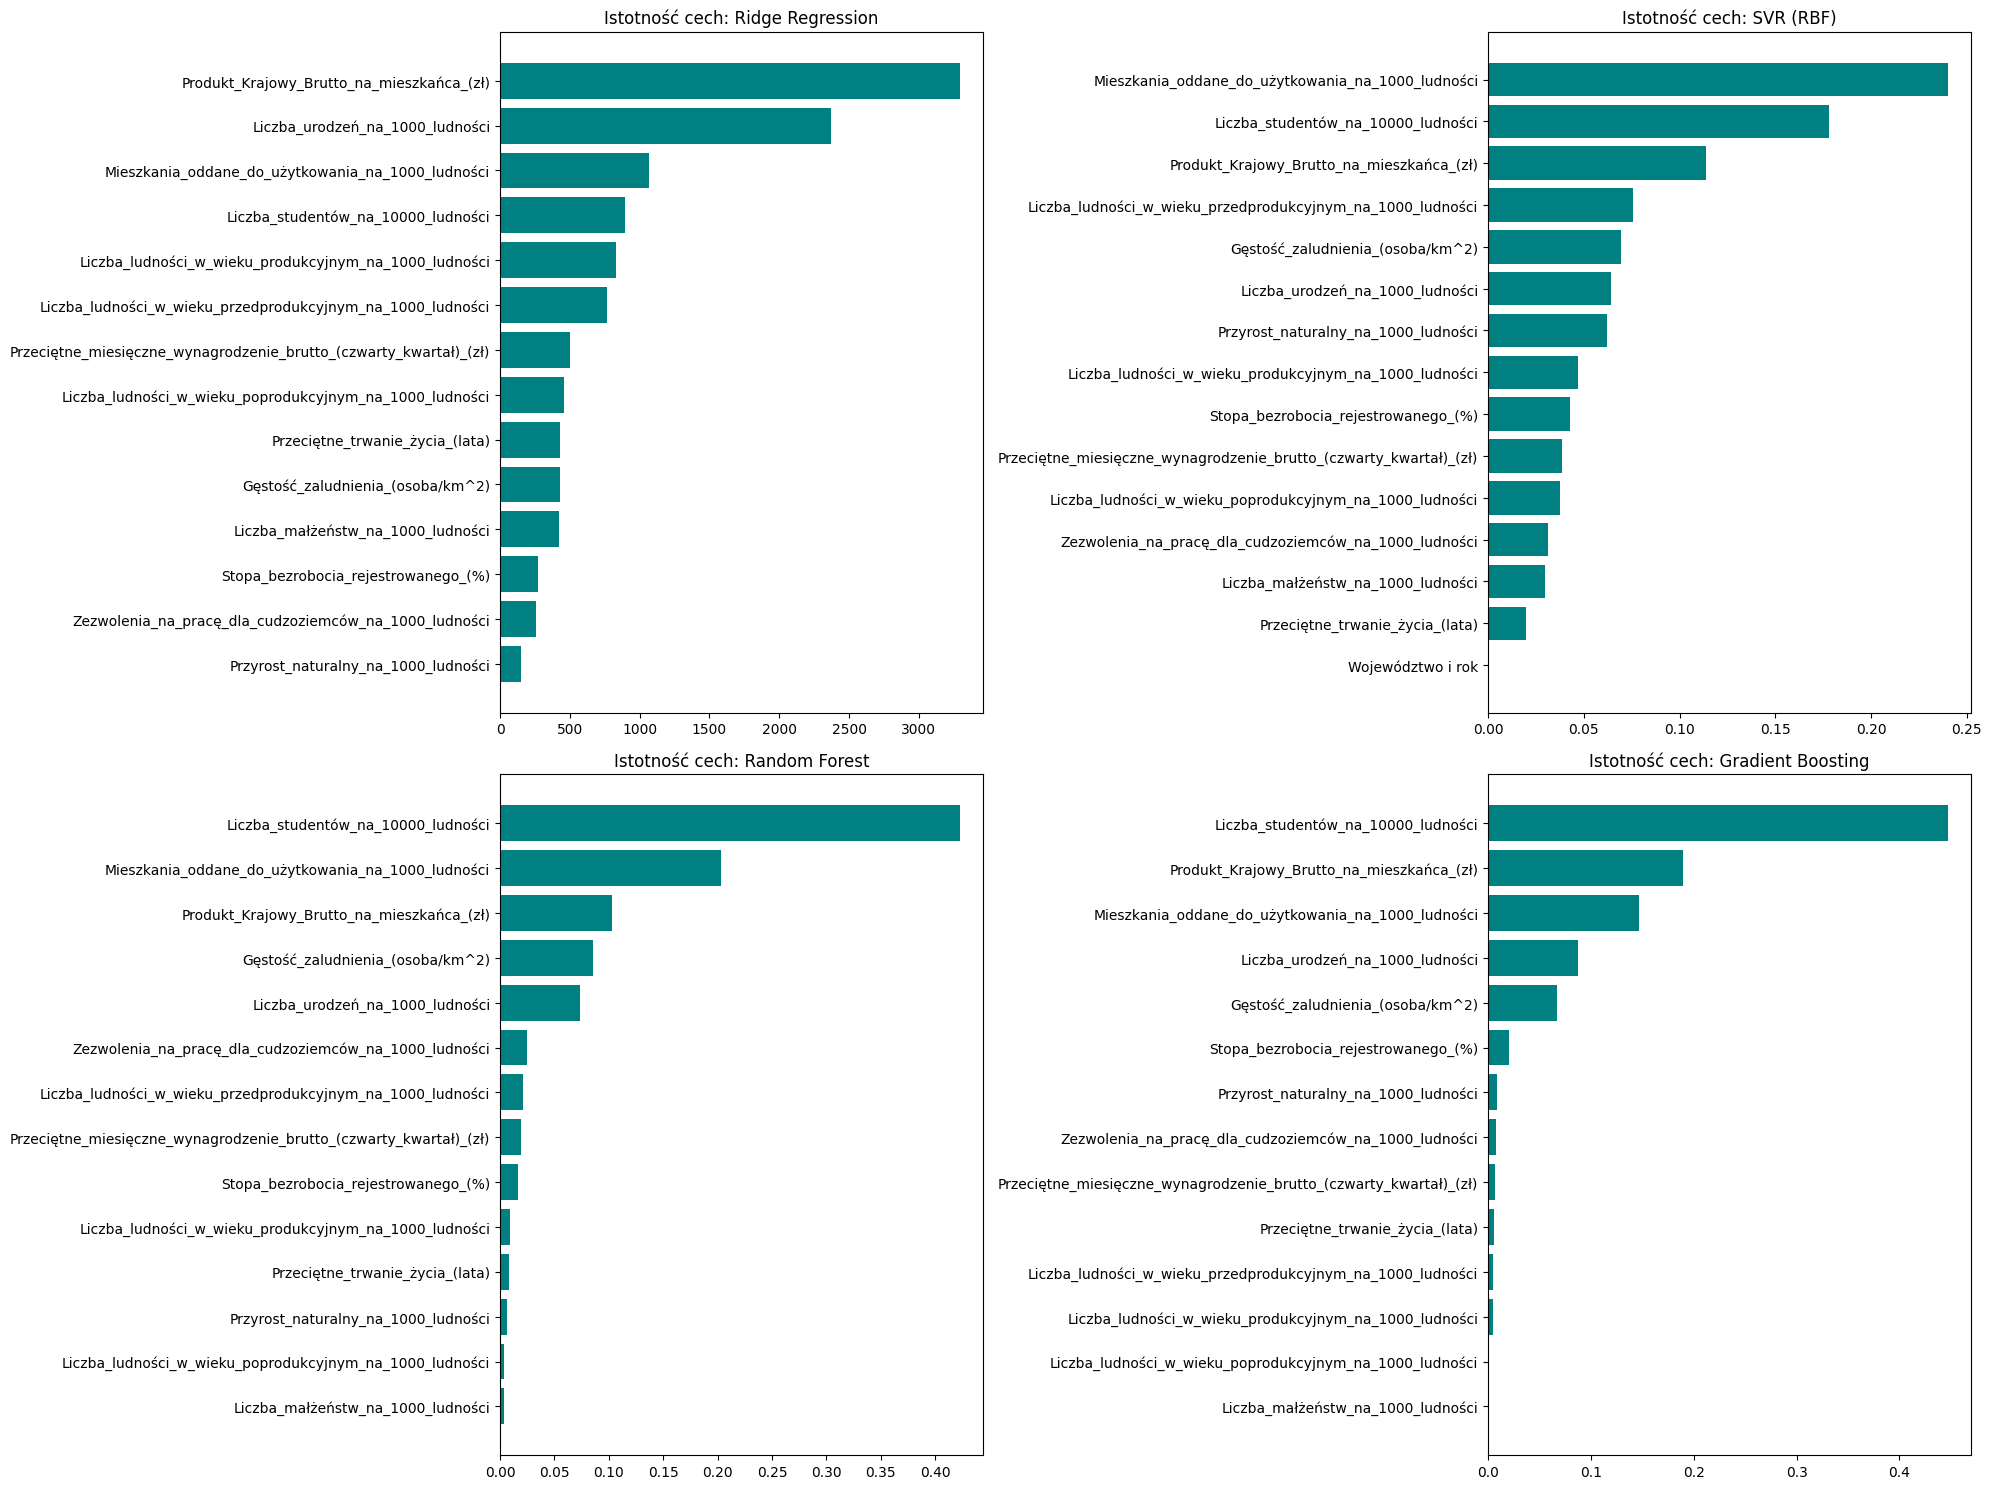

In [ ]:
#Porównanie modeli

feature_importance_dict = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('regressor', model)
    ])

    #Pomiar czasu i trenowanie
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start_time

    #Predykcje
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    #Metryki
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)

    #Walidacja krzyżowa (R2)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')

    results_list.append({ #Dodanie do lsity wyników
        'Metoda': name,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Cross-val R2 mean': cv_scores.mean(),
        'Czas trenowania [s]': train_time,
        'Liczba cech': X_train.shape[1]
    })

    print(f"Zakończono trenowanie: {name}")

     #Feature Importance
    current_feature_names = []
    if name == 'Ridge Regression':
        #Dla Ridge bierzemy wartości bezwzględne współczynników
        importance = np.abs(pipeline.named_steps['regressor'].coef_)
        current_feature_names = num_features.tolist()
    elif name in ['Random Forest', 'Gradient Boosting']:
        #Dla drzew bierzemy wbudowaną istotność
        importance = pipeline.named_steps['regressor'].feature_importances_
        current_feature_names = num_features.tolist()
    else: #Dla SVR (RBF) używamy Permutation Importance
        print(f"Obliczam Permutation Importance dla {name} (to może chwilę potrwać)...")
        result = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=42)
        importance = result.importances_mean
        current_feature_names = X.columns.tolist()

    feature_importance_dict[name] = (importance, current_feature_names)

#Tabela feature importances
results_base = pd.DataFrame(results_list)
display(results_base)

plt.figure(figsize=(20, 15))
for i, (name, (importance, current_feature_names)) in enumerate(feature_importance_dict.items()):
    plt.subplot(2, 2, i+1)
    indices = np.argsort(importance)
    plt.barh(range(len(indices)), importance[indices], color='teal', align='center')
    plt.yticks(range(len(indices)), [current_feature_names[j] for j in indices])
    plt.title(f'Istotność cech: {name}')
plt.tight_layout()
plt.show()

In [ ]:
# plt.figure(figsize=(12, 6))

# #Random Forest
# plt.subplot(1, 2, 1)
# plt.scatter(np.expm1(y_test), np.expm1(rf_model.predict(X_test)), alpha=0.5)
# plt.plot([0, 7e5], [0, 7e5], 'r--')
# plt.xlabel('Rzeczywista ')
# plt.ylabel('Predykcje RF ($)')
# plt.title(f'Random Forest (R²={rf_metrics["Test R2"]:.3f})')
# plt.xlim(0, 7e5)
# plt.ylim(0, 7e5)

# #Gradient Boosting
# plt.subplot(1, 2, 2)
# plt.scatter(np.expm1(y_test), np.expm1(gb_model.predict(X_test)), alpha=0.5)
# plt.plot([0, 7e5], [0, 7e5], 'r--')
# plt.xlabel('Rzeczywiste ceny ($)')
# plt.ylabel('Predykcje GB ($)')
# plt.title(f'Gradient Boosting (R²={gb_metrics["Test R2"]:.3f})')
# plt.xlim(0, 7e5)
# plt.ylim(0, 7e5)

# plt.tight_layout()
# plt.show()

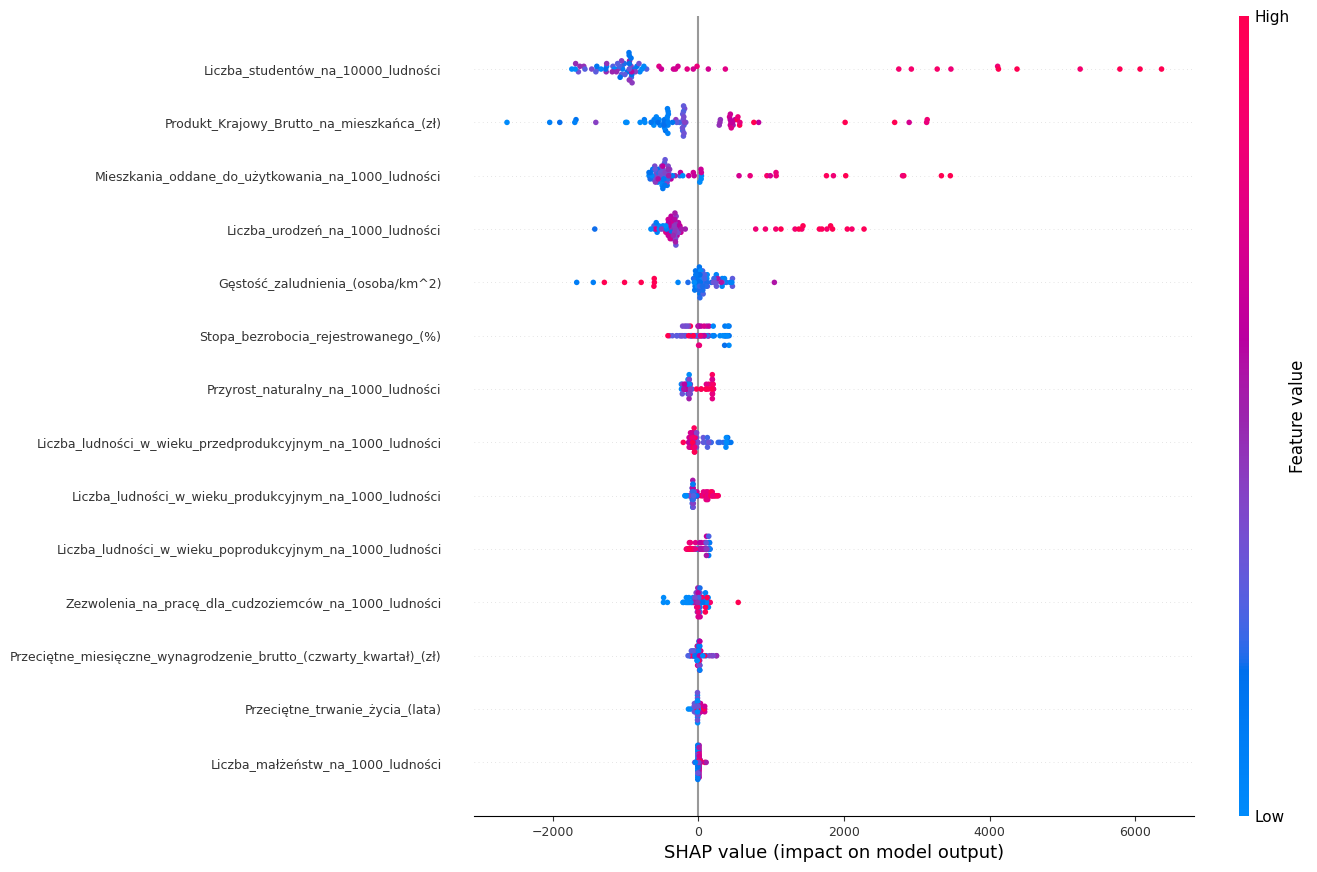

In [ ]:
import shap

#Przygotowanie danych
best_model = pipeline
X_test_preprocessed = preprocessor.transform(X_test)
X_test_df = pd.DataFrame(X_test_preprocessed, columns=current_feature_names)

#Inicjalizacja Explainaera
explainer = shap.TreeExplainer(pipeline.named_steps['regressor'])
shap_values = explainer.shap_values(X_test_preprocessed)
plt.figure(figsize=(15, 10))
shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type="dot",
    show=False,
    plot_size=(15, 10)
)
#Ręczne ustawienie lewego marginesu.
#Wartość 0.3 - 0.4 daje dużo miejsca na bardzo długie nazwy cech po lewej stronie
plt.subplots_adjust(left=0.35, right=0.95, top=0.9, bottom=0.1)
plt.yticks(fontsize=9)
plt.xticks(fontsize=9)

plt.show()

# Analiza głównych składowych PCA

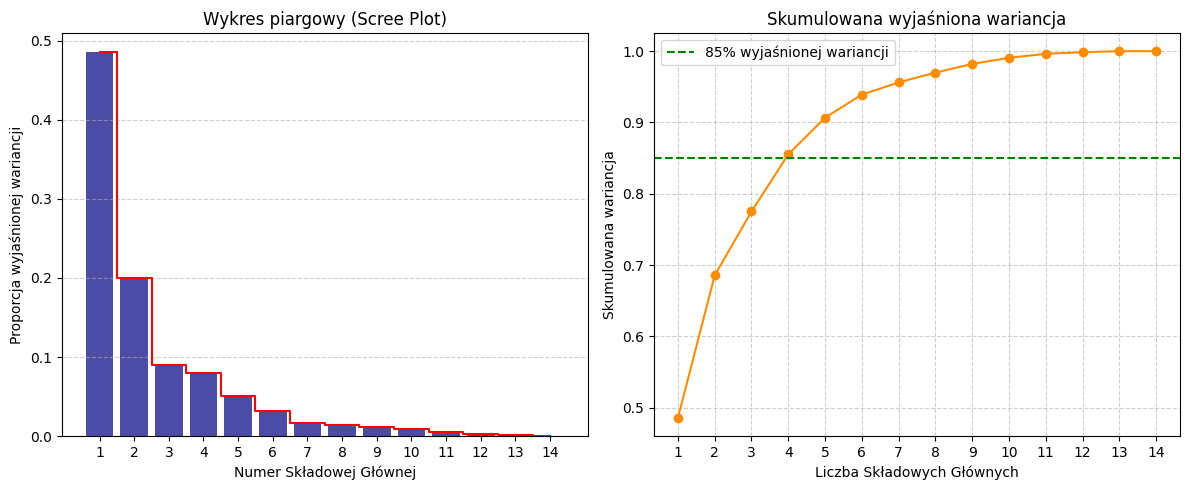


Minimalna liczba składowych do wyjaśnienia 85% wariancji: 4
Minimalna liczba składowych do wyjaśnienia 90% wariancji: 5
Minimalna liczba składowych do wyjaśnienia 100% wariancji: 10


In [ ]:
X_PCA = MigracjeZbiór.drop(['Saldo_migracji_wewnętrznych', 'Województwo i rok'], axis=1)

#Standaryzacja
scaler = StandardScaler()
X_scaled_PCA = scaler.fit_transform(X_PCA)

#Pełne PCA (tyle składowych, ile cech)
pca_full = PCA()
pca_full.fit(X_scaled_PCA)

#Obliczenie wariancji
explained_variance = pca_full.explained_variance_ratio_
cumsum_explained = np.cumsum(explained_variance)

plt.figure(figsize=(12, 5)) #Scree Plot & Cumulative Plot

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='navy', label='Pojedyncza składowa')
plt.step(range(1, len(explained_variance) + 1), explained_variance, where='mid', color='red')
plt.title('Wykres piargowy (Scree Plot)')
plt.xlabel('Numer Składowej Głównej')
plt.ylabel('Proporcja wyjaśnionej wariancji')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum_explained) + 1), cumsum_explained, marker='o', linestyle='-', color='darkorange')
plt.axhline(y=0.85, color='green', linestyle='--', label='85% wyjaśnionej wariancji')
plt.title('Skumulowana wyjaśniona wariancja')
plt.xlabel('Liczba Składowych Głównych')
plt.ylabel('Skumulowana wariancja')
plt.xticks(range(1, len(cumsum_explained) + 1))
plt.legend()
plt.grid(linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#Określenie minimalnej liczby składowych potrzebnych do osiągnięcia progu
def components_for_threshold(cumsum_var, threshold):
    idx = np.argmax(cumsum_var >= threshold)
    #jeśli żaden element nie spełnia (np. threshold>max), wtedy return len(cumsum_var)
    if cumsum_var[-1] < threshold:
        return len(cumsum_var)
    return idx + 1  # +1 bo index od 0, składowe liczy się od 1

n85 = components_for_threshold(cumsum_explained, 0.85)
n90 = components_for_threshold(cumsum_explained, 0.90)
n100 = components_for_threshold(cumsum_explained, 0.99)

print(f"\nMinimalna liczba składowych do wyjaśnienia 85% wariancji: {n85}")
print(f"Minimalna liczba składowych do wyjaśnienia 90% wariancji: {n90}")
print(f"Minimalna liczba składowych do wyjaśnienia 100% wariancji: {n100}")

**Analiza wpływu wybranej liczby składowych na dokładność modeli**

In [ ]:
#Definicja modeli do testów PCA
models_pca = {
    'Ridge': Ridge(),
    'SVR (RBF)': SVR(kernel='rbf', C=1000, epsilon=0.1, gamma='auto'), # SVR z poprzedniego gridsearch
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# Przygotowanie listy k (usuwamy n100 jeśli to po prostu max cech, dodajemy max_components)
max_components = X_PCA.shape[1]
k_list = [2, 3, 4, 5, 7, 10, 14]
k_list = sorted(list({k for k in k_list if 1 <= k <= max_components}))

results_pca = []

print(f"Rozpoczynam testy dla k: {k_list}")

for k in k_list:
    #Obliczamy sumę wyjaśnionej wariancji dla danego k
    var_sum = float(np.sum(pca_full.explained_variance_ratio_[:k]))

    for model_name, model in models_pca.items():
        pipeline_pca = Pipeline([
            ('preprocessing', preprocessor), #pipeline dla PCA
            ('pca', PCA(n_components=k)),
            ('regressor', model)
        ])

        t0 = time.time()
        pipeline_pca.fit(X_train, y_train)
        t_train = time.time() - t0

        y_pred_train = pipeline_pca.predict(X_train)
        y_pred_test = pipeline_pca.predict(X_test)

        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)

        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

        train_mae = mean_absolute_error(y_train, y_pred_train)
        test_mae = mean_absolute_error(y_test, y_pred_test)

        #Walidacja krzyżowa (R2)
        cv_scores = cross_val_score(pipeline_pca, X_train, y_train, cv=5, scoring='r2')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()

        results_pca.append({
            'Model': model_name,
            'k': k,
            'explained_variance_sum': var_sum,
            'Train R2': train_r2,
            'Test R2': test_r2,
            'Train RMSE': train_rmse,
            'Test RMSE': test_rmse,
            'Train MAE': train_mae,
            'Test MAE': test_mae,
            'Cross-val R2 mean': cv_mean,
            'Cross-val std': cv_std,
            'Czas trenowania [s]': t_train
        })

results_pca_df = pd.DataFrame(results_pca)
#Sortujemy dla lepszej czytelności: najpierw model, potem liczba składowych
results_pca_df = results_pca_df.sort_values(by=['Model', 'k']).reset_index(drop=True)

pd.options.display.max_rows = None #Aby zobaczyć wszystkie kombinacje
display(results_pca_df)

Rozpoczynam testy dla k: [2, 3, 4, 5, 7, 10, 14]


,Model,k,explained_variance_sum,Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Cross-val R2 mean,Cross-val std,Czas trenowania [s]
0,Gradient Boosting,2,0.685562,0.946237,0.543823,954.793487,2659.222798,705.017690,1691.414191,0.582516,0.074390,0.149745
1,Gradient Boosting,3,0.775106,0.973147,0.744541,674.786561,1989.976807,509.875702,1348.091126,0.772891,0.047143,0.098249
2,Gradient Boosting,4,0.855266,0.980781,0.750918,570.868333,1964.982674,436.339643,1196.733002,0.824188,0.111939,0.106936
3,Gradient Boosting,5,0.906722,0.985217,0.768811,500.668883,1893.089191,372.611727,1230.725682,0.831871,0.111035,0.121075
4,Gradient Boosting,7,0.956227,0.995388,0.874106,279.660411,1396.982007,217.681493,891.323336,0.877671,0.069009,0.195030
5,Gradient Boosting,10,0.990655,0.996241,0.872817,252.469443,1404.116127,192.331931,921.890781,0.902648,0.053261,0.197868
6,Gradient Boosting,14,1.000000,0.997299,0.882395,214.017078,1350.207406,166.184311,946.174792,0.838990,0.093418,0.218409
7,Random Forest,2,0.685562,0.952759,0.548602,895.010433,2645.254940,641.286012,1726.481944,0.635136,0.079367,0.333294
8,Random Forest,3,0.775106,0.971851,0.768873,690.871118,1892.837991,488.519762,1293.567639,0.804332,0.045563,0.306865
9,Random Forest,4,0.855266,0.971963,0.773474,689.506220,1873.903483,474.651964,1191.820278,0.791629,0.089180,0.197128


In [ ]:
# Definicja kerneli i parametrów- dla jądra liniowego gamma jest ignorowana, więc jest [None]
kernels_config = {
    'Linear': [None],
    'RBF': [0.001, 0.01, 0.1]
}

models_pca = {
    'Ridge': Ridge(),
    'SVR_Tuned': SVR(kernel='rbf', C=1000, epsilon=0.1, gamma='auto'),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

k_list = [3, 4, 5, 10, 14]
max_components = X_PCA.shape[1]
k_list = sorted(list({k for k in k_list if 1 <= k <= max_components}))

results_kpca = []

print(f"Rozpoczynam testy Kernel PCA dla k: {k_list}")

for k in k_list:
    for kernel_name, gammas in kernels_config.items():
        for g in gammas:
            for model_name, model in models_pca.items():

                #Konfiguracja Kernel PCA
                if kernel_name == 'Linear':
                    kpca = KernelPCA(n_components=k, kernel='linear')
                    var_sum = float(np.sum(pca_full.explained_variance_ratio_[:k]))
                else:
                    kpca = KernelPCA(n_components=k, kernel='rbf', gamma=g)
                    var_sum = None #KPCA RBF nie podaje wariancji wprost

                pipeline_kpca = Pipeline([
                    ('preprocessing', preprocessor),
                    ('pca', kpca),
                    ('regressor', model)
                ])

                t0 = time.time()
                pipeline_kpca.fit(X_train, y_train)
                t_train = time.time() - t0

                y_pred_train = pipeline_kpca.predict(X_train)
                y_pred_test = pipeline_kpca.predict(X_test)

                train_r2 = r2_score(y_train, y_pred_train)
                test_r2 = r2_score(y_test, y_pred_test)
                train_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
                train_mae = mean_absolute_error(y_test, y_pred_test)

                cv_scores = cross_val_score(pipeline_kpca, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

                results_kpca.append({
                    'Model': model_name,
                    'k': k,
                    'Kernel': kernel_name,
                    'Gamma': g if g is not None else 'N/A',
                    'Expl_Var_Sum': var_sum,
                    'Train R2': train_r2,
                    'Test R2': test_r2,
                    'Test RMSE': train_rmse,
                    'Test MAE': train_mae,
                    'CV R2 Mean': cv_scores.mean(),
                    'CV R2 Std': cv_scores.std(),
                    'Czas [s]': t_train
                })

results_kpca_df = pd.DataFrame(results_kpca)
#Sortowanie dla łatwego porównania wpływu Gammy i Kernela
results_kpca_df = results_kpca_df.sort_values(by=['Model', 'Kernel', 'k', 'Gamma']).reset_index(drop=True)

pd.options.display.max_rows = None
display(results_kpca_df)

Rozpoczynam testy Kernel PCA dla k: [3, 4, 5, 10, 14]


,Model,k,Kernel,Gamma,Expl_Var_Sum,Train R2,Test R2,Test RMSE,Test MAE,CV R2 Mean,CV R2 Std,Czas [s]
0,Gradient Boosting,3,Linear,N/A,0.775106,0.973147,0.742879,1996.441782,1350.083927,0.772696,0.047762,0.180741
1,Gradient Boosting,4,Linear,N/A,0.855266,0.980781,0.752542,1958.567415,1185.067502,0.822840,0.110370,0.146777
2,Gradient Boosting,5,Linear,N/A,0.906722,0.985217,0.777673,1856.454700,1213.673024,0.838193,0.110720,0.150293
3,Gradient Boosting,10,Linear,N/A,0.990655,0.996241,0.872641,1405.085545,924.633849,0.905507,0.056510,0.202114
4,Gradient Boosting,14,Linear,N/A,1.000000,0.997299,0.861355,1466.022019,982.979859,0.849621,0.096998,0.380318
5,Gradient Boosting,3,RBF,0.001,NaN,0.975198,0.731220,2041.203754,1390.895092,0.757196,0.094094,0.181976
6,Gradient Boosting,3,RBF,0.01,NaN,0.973020,0.604997,2474.502120,1664.421855,0.694370,0.102553,0.142386
7,Gradient Boosting,3,RBF,0.1,NaN,0.933715,0.492297,2805.387141,1936.048649,0.521983,0.044524,0.142134
8,Gradient Boosting,4,RBF,0.001,NaN,0.979425,0.744149,1991.503416,1252.710959,0.815009,0.117496,0.145548
9,Gradient Boosting,4,RBF,0.01,NaN,0.978431,0.651047,2325.792975,1549.495439,0.729808,0.103689,0.188125


/tmp/ipykernel_2699/4022551921.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


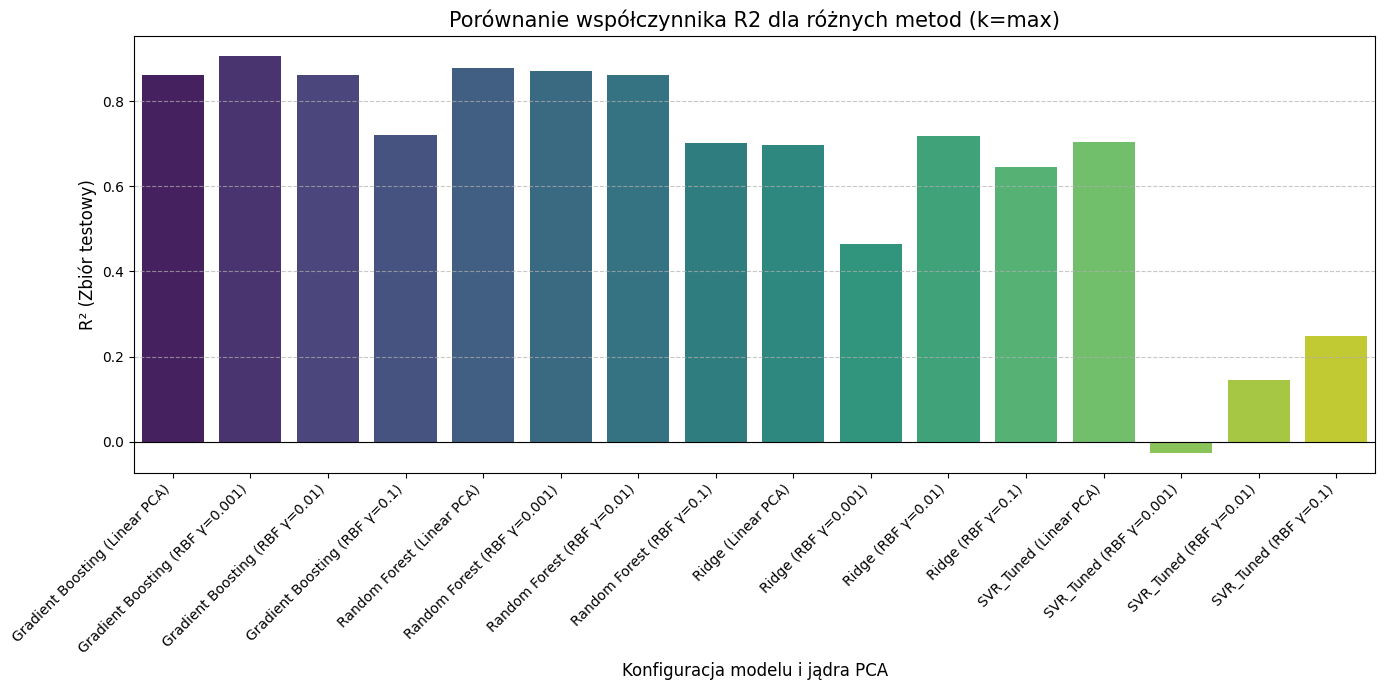

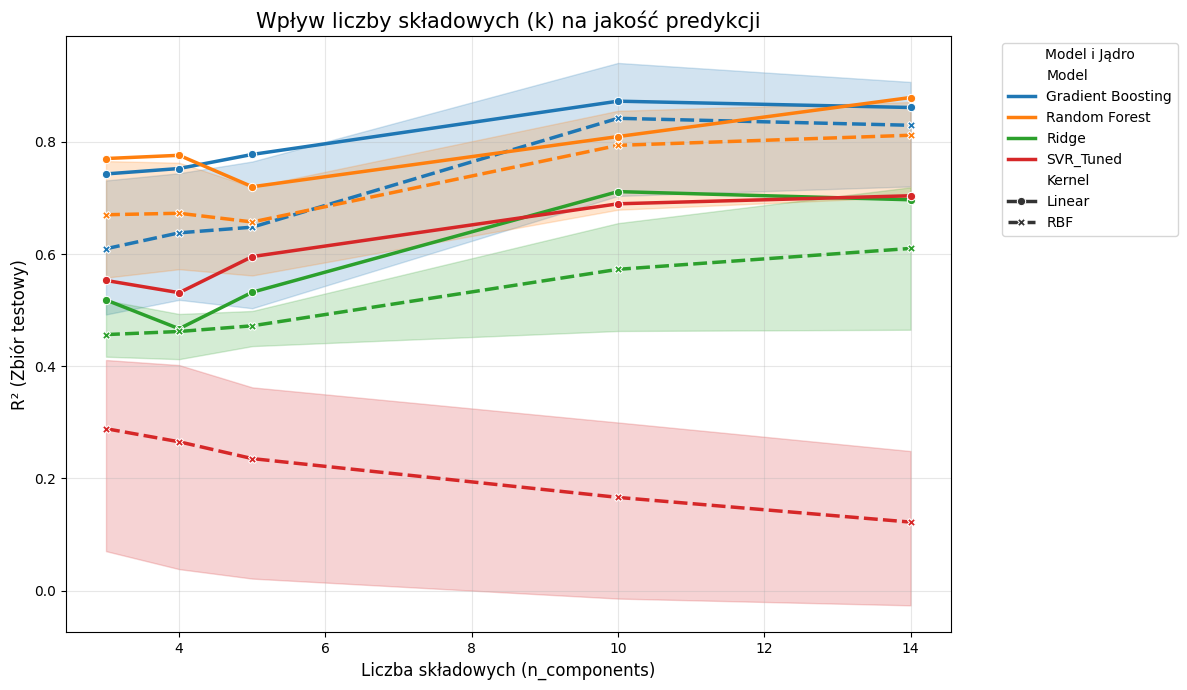

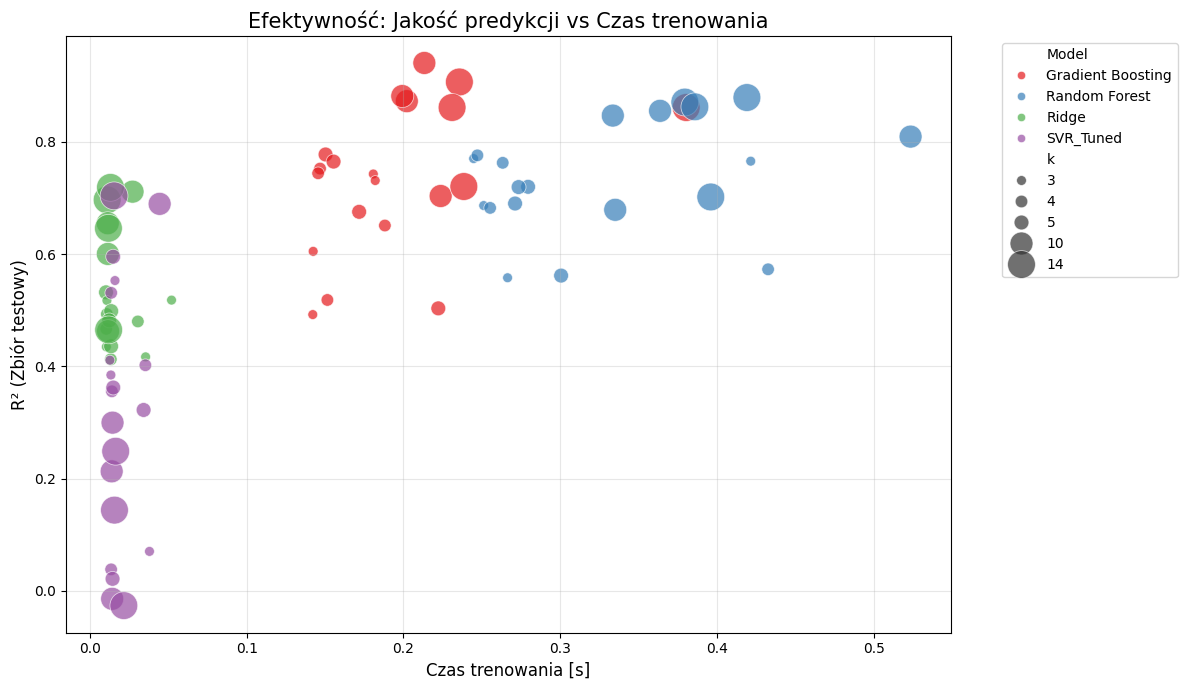

In [ ]:
#Tworzenie wykresów
df_plot = results_kpca_df.copy()

def create_label(row):
    if row['Kernel'] == 'Linear':
        return f"{row['Model']} (Linear PCA)"
    else:
        return f"{row['Model']} (RBF γ={row['Gamma']})"

df_plot['Metoda_Full'] = df_plot.apply(create_label, axis=1)

#Wykres 1: Porównanie R2 dla najlepszych konfiguracji (Barplot)
#Wybieramy np. najwyższe k=14, żeby zobaczyć maksymalny potencjał modeli
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_plot[df_plot['k'] == df_plot['k'].max()],
    x='Metoda_Full',
    y='Test R2',
    palette='viridis'
)
plt.title('Porównanie współczynnika R2 dla różnych metod (k=max)', fontsize=15)
plt.ylabel('R² (Zbiór testowy)', fontsize=12)
plt.xlabel('Konfiguracja modelu i jądra PCA', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8) # Linia zero
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Wykres 2: R2 vs Liczba składowych (Lineplot)
#To najważniejszy wykres- pokazuje wpływ redukcji wymiarów
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_plot,
    x='k',
    y='Test R2',
    hue='Model',
    style='Kernel',
    markers=True,
    dashes=True,
    linewidth=2.5
)
plt.title('Wpływ liczby składowych (k) na jakość predykcji', fontsize=15)
plt.xlabel('Liczba składowych (n_components)', fontsize=12)
plt.ylabel('R² (Zbiór testowy)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Model i Jądro')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Wykres 3: R2 vs Czas trenowania
plt.figure(figsize=(12, 7))
scatter = sns.scatterplot(
    data=df_plot,
    x='Czas [s]',
    y='Test R2',
    hue='Model',
    size='k',
    sizes=(50, 400),
    alpha=0.7,
    palette='Set1'
)
plt.title('Efektywność: Jakość predykcji vs Czas trenowania', fontsize=15)
plt.xlabel('Czas trenowania [s]', fontsize=12)
plt.ylabel('R² (Zbiór testowy)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analiza Ładunków czynnikowych

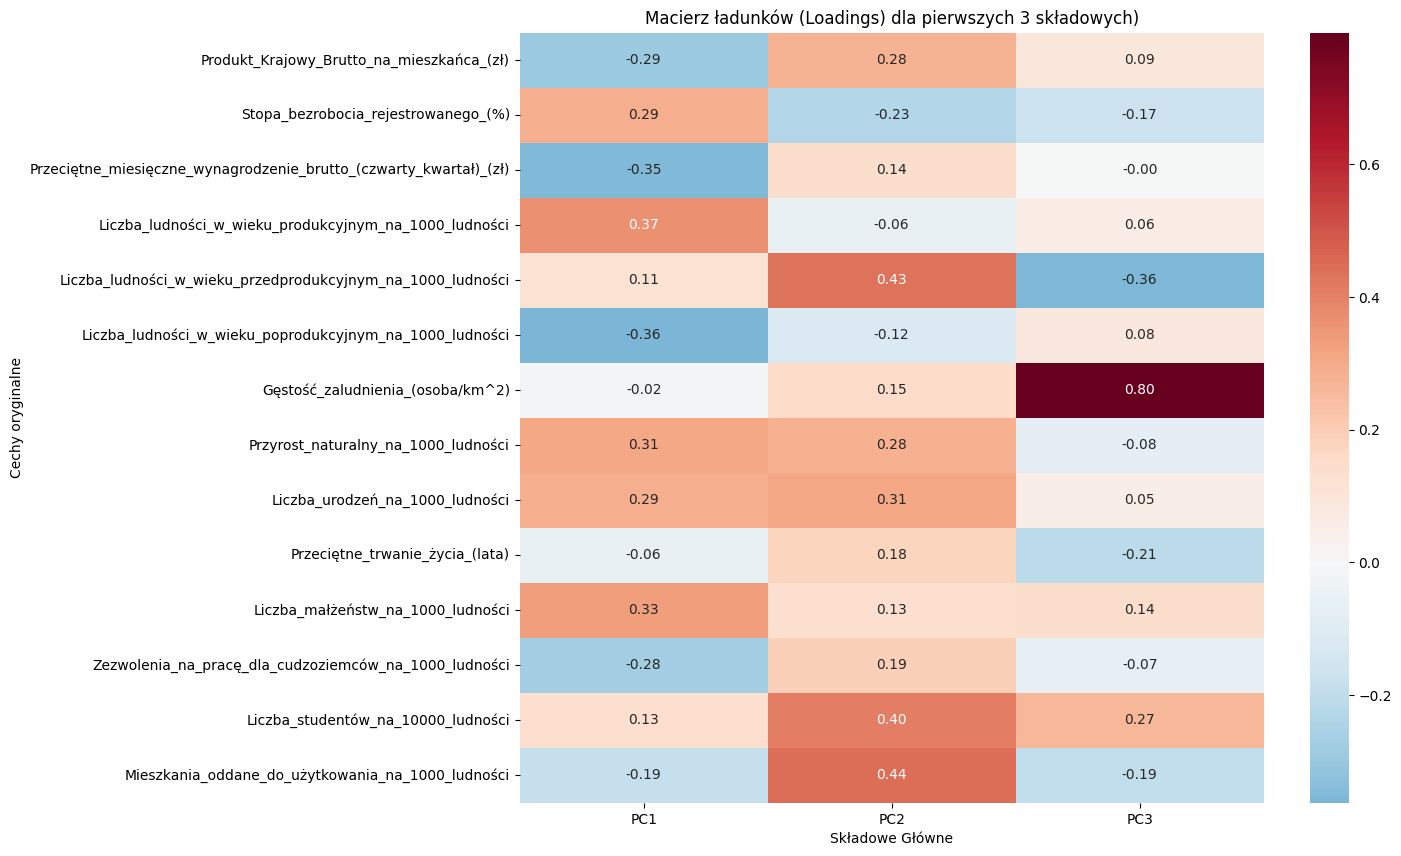

In [ ]:
#Analiza składu
#Tworzymy DataFrame z ładunkami
#Wiersze to składowe, kolumny to  oryginalne cechy
loadings = pd.DataFrame(
    pca_full.components_.T,  #Transpozycja, aby cechy były w wierszach
    columns=[f'PC{i+1}' for i in range(len(X_PCA.columns))],
    index=X_PCA.columns
)

#Tylko te składowe, które mieszczą się w danym progu
n_plot = 3
loadings_subset = loadings.iloc[:, :n_plot]

plt.figure(figsize=(12, 10))
sns.heatmap(loadings_subset, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title(f'Macierz ładunków (Loadings) dla pierwszych {n_plot} składowych)')
plt.ylabel('Cechy oryginalne')
plt.xlabel('Składowe Główne')
plt.show()

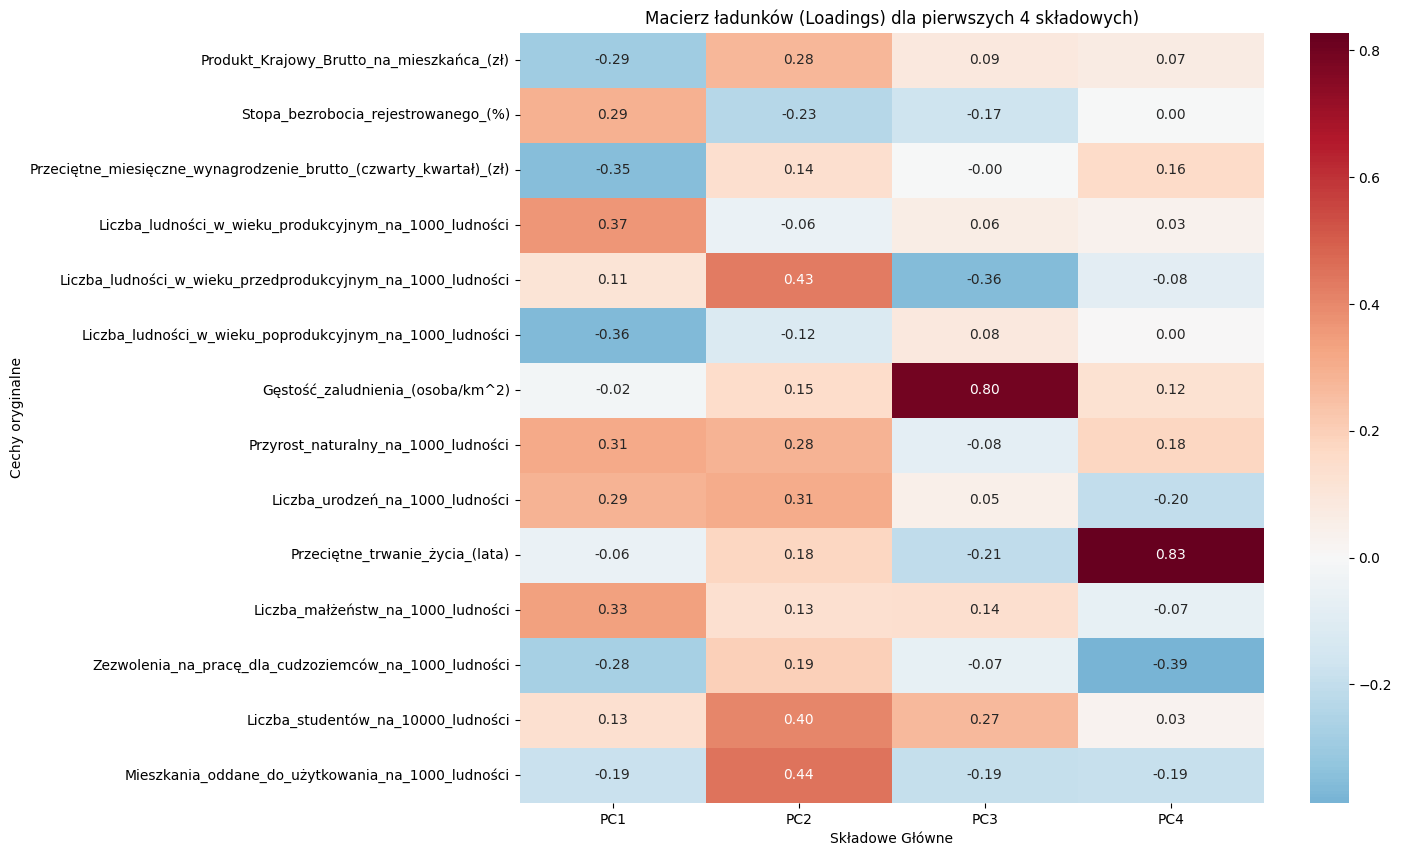

In [ ]:

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(X_PCA.columns))],
    index=X_PCA.columns
)

n_plot = 4
loadings_subset = loadings.iloc[:, :n_plot]

plt.figure(figsize=(12, 10))
sns.heatmap(loadings_subset, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title(f'Macierz ładunków (Loadings) dla pierwszych {n_plot} składowych)')
plt.ylabel('Cechy oryginalne')
plt.xlabel('Składowe Główne')
plt.show()

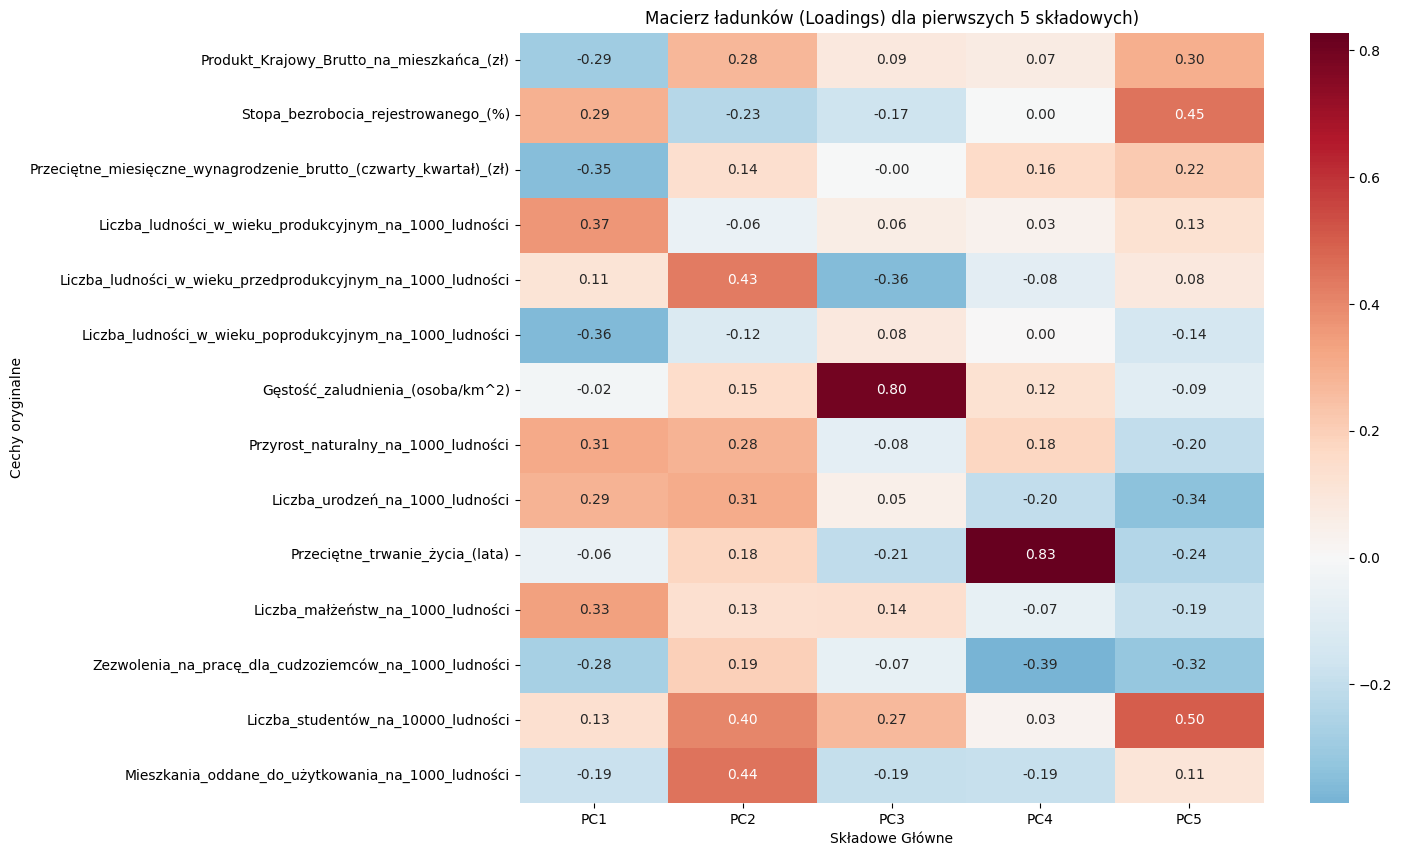

In [ ]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(X_PCA.columns))],
    index=X_PCA.columns
)

n_plot = 5
loadings_subset = loadings.iloc[:, :n_plot]

plt.figure(figsize=(12, 10))
sns.heatmap(loadings_subset, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title(f'Macierz ładunków (Loadings) dla pierwszych {n_plot} składowych)')
plt.ylabel('Cechy oryginalne')
plt.xlabel('Składowe Główne')
plt.show()

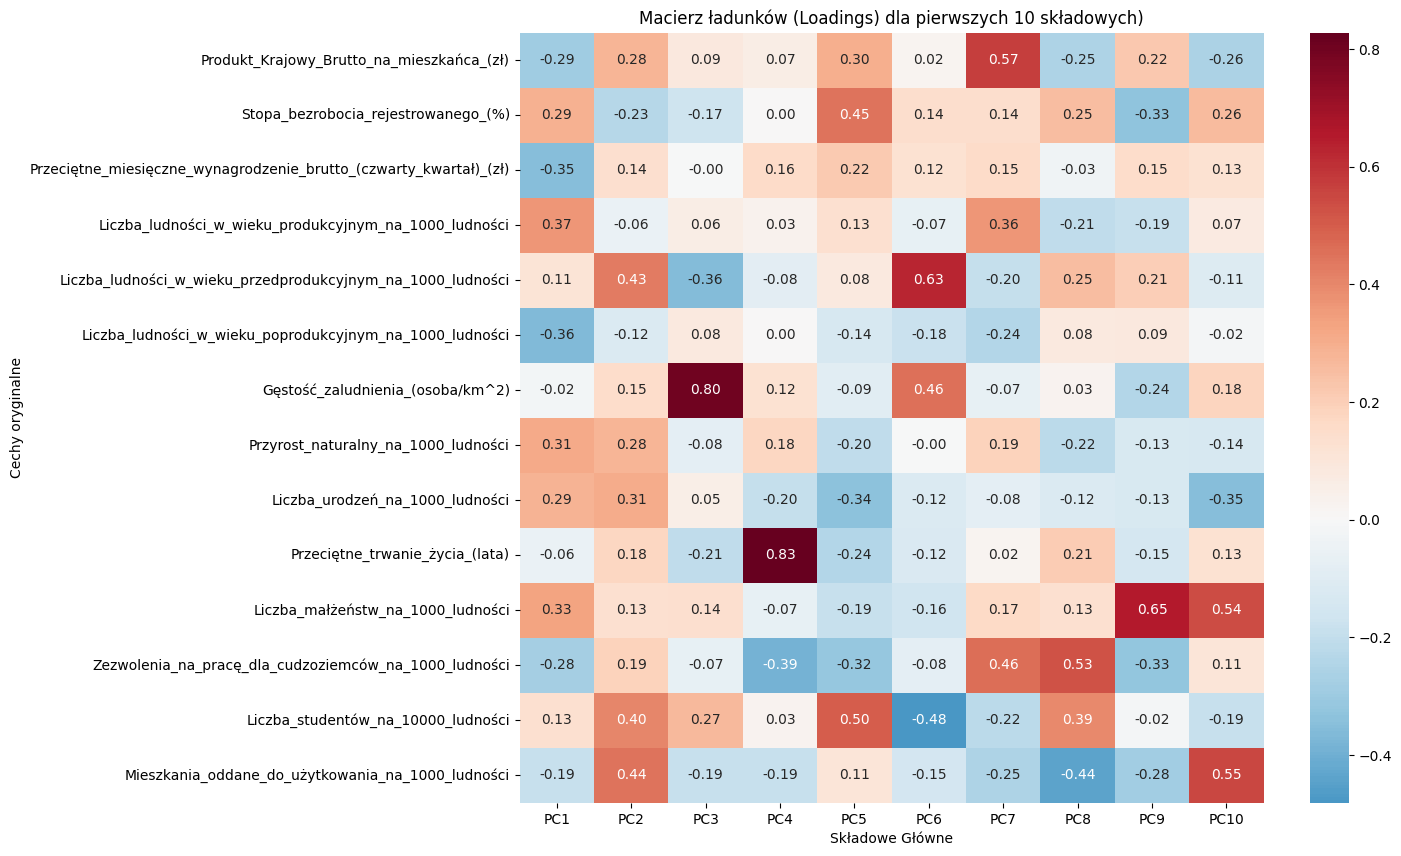

In [ ]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(X_PCA.columns))],
    index=X_PCA.columns
)

n_plot = 10
loadings_subset = loadings.iloc[:, :n_plot]

plt.figure(figsize=(12, 10))
sns.heatmap(loadings_subset, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title(f'Macierz ładunków (Loadings) dla pierwszych {n_plot} składowych)')
plt.ylabel('Cechy oryginalne')
plt.xlabel('Składowe Główne')
plt.show()

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

#Przygotowanie danych podstawowych
df_pca = pd.DataFrame(X_pca_transformed[:, 0:2], columns=['PC1', 'PC2'])
df_pca['Label_Full'] = MigracjeZbiór['Województwo i rok']
df_pca['Saldo'] = MigracjeZbiór['Saldo_migracji_wewnętrznych']

#Rozbicie nazwy- separator "_"
df_pca['Województwo'] = df_pca['Label_Full'].str.rsplit('_', n=1).str[0]
df_pca['Rok'] = df_pca['Label_Full'].str.rsplit('_', n=1).str[1]

loadings = pca_full.components_[0:2, :].T
features = X_PCA.columns
scale_factor = max(df_pca['PC1'].abs().max(), df_pca['PC2'].abs().max()) * 0.8

#Tworzenie bazowego wykresu punktowego
fig = px.scatter(
    df_pca,
    x='PC1',
    y='PC2',
    color='Województwo',
    hover_data={'Label_Full': True, 'Saldo': True, 'PC1': ':.2f', 'PC2': ':.2f'},
    title='Interaktywny Biplot PCA: Wektory cech i trajektorie województw',
    labels={'PC1': 'Składowa Główna 1', 'PC2': 'Składowa Główna 2'},
    template='plotly_white',
    opacity=0.6
)

#Dodawanie wektorów cech
for i, feature in enumerate(features):
    x_end = loadings[i, 0] * scale_factor
    y_end = loadings[i, 1] * scale_factor
    fig.add_annotation(
        ax=0, ay=0,             #Początek strzałki (środek układu)
        axref='x', ayref='y',
        x=x_end, y=y_end,       #Koniec strzałki
        xref='x', yref='y',
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor="red"
    )

    #Dodawanie nazw cech przy końcach strzałek
    fig.add_annotation(
        x=x_end * 1.1, y=y_end * 1.1,
        text=feature,
        showarrow=False,
        font=dict(color="darkgreen", size=12, family="Arial Black"),
        xref='x', yref='y'
    )

fig.update_traces(marker=dict(size=9, line=dict(width=1, color='DarkGrey')))
fig.update_layout(
    height=1100,
    width=1200,
    legend_title_text='Województwa',
    hoverlabel=dict(bgcolor="white", font_size=13)
)

fig.add_hline(y=0, line_dash="dash", line_color="lightgrey")
fig.add_vline(x=0, line_dash="dash", line_color="lightgrey")

fig.show()